# E5 · Exact effect of each drift — paired counterfactual (v2)

**Why.** The study's dependence evidence compares a world's settled window with its init window and decides with a
null calibrated on branch links; on loops that null was untested (U3), and the probe stack's labels disagreed with the
target worlds' (U4). The labels only need the effect of **the drift each world actually has**, and that can be
simulated exactly.

**Counterfactual.** Demand synthesis draws every (node, month) from its own generator keyed by (seed, month, node),
and only drifting nodes change their land-use cohorts. In a set of worlds that share a seed and differ only in which
district drifts, district $d$'s demand is therefore identical in every world where $d$ does not drift. The **no-drift
city** is spliced from those columns (G-E5a), simulated once per partition, and every drift world is compared with it
hour by hour: $\Delta Q_s(t)=Q^{(k)}_s(t)-Q^{(0)}_s(t)$ is the drift's exact effect on link $s$.

| set | worlds | answers |
|---|---|---|
| target | the study's worlds (seed 43), with the study's init / settled windows | U3; the target labels |
| probe | the label stack's probe worlds (seed 42), with the stack's windows | the stack's gate scored on exact truth; U4 |

**Changes from v1.** v1's reference metric RE (hour-level relative change) turned out district-blind: a drift anywhere
reshuffles pump and tank switching, so almost every storage-coupled link "responds" to every drift. v2 labels with the
native projection gain $N$ and the shape effect $S$, separately and composed ($C$); RE stays as a diagnostic. The
G-E5e shape gate now orients the recomputed gain like `sensor_evidence` (written by `dependence_analysis` v4, §6).
New: metrics per period (init / transition / final) and per month; a sweep of the relevance floors (S); sanity figures
and sensor cards that show what each label summarises in the pipes (P); the target labels (L).

In [1]:
%matplotlib inline
import warnings, logging, sys, pathlib, json, datetime, time, copy, ctypes, tempfile
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import networkx as nx
import yaml
import ipywidgets as ipw
from matplotlib.colors import LogNorm, TwoSlopeNorm
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scipy.stats import mannwhitneyu, spearmanr

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"
LAB_DIR = REPO / "notebooks" / "fedwater_lab_refactor"     # adjust to your layout
for p in (REPO / "src", LAB_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
import wntr
from wntr.epanet import toolkit
from wntr.network.io import write_inpfile
from wntr.network.controls import Control, ControlAction
from fedwater.pipelines.network_prep.nodes import configure_network, apply_coupling     # read-only
from fedwater.pipelines.hydraulics.nodes import run_hydraulics, scratch_root, _remove, UNIT_BASE_SI
from fedwater.placement import signal_probe as sp
from fedwater.placement import store
from fedwater.reporting import Atlas

warnings.filterwarnings("ignore")
logging.getLogger("kedro").setLevel(logging.WARNING)
pd.set_option("display.width", 230, "display.max_columns", 60, "display.max_rows", 300)
plt.rcParams.update({"figure.dpi": 90, "font.size": 8})

EXPERIMENTS = None              # None -> <project>/data/09_experiments
STUDY = "ky72_districting_all_districts"                    # set explicitly per network
ATLAS = Atlas(root=EXPERIMENTS)
WORLDS = ATLAS.worlds(STUDY, ok_only=True).reset_index(drop=True)
BASE = REPO / "notebooks" / "outputs" / STUDY
OUT = BASE / "epanet_e5"
OUT.mkdir(parents=True, exist_ok=True)
SERIES = OUT / "series"
SERIES.mkdir(exist_ok=True)

# which sets run
RUN_TARGET, RUN_PROBE = True, True        # the study's worlds (seed 43) / the label stack's probe worlds (seed 42)
FINE_STEP = 900                           # second hydraulic step (s); None = 3600 s only
FINE_NETWORKS = {"ky72"}                 # networks where the 1 h step was shown not to have converged (E0c)

# label metrics and their floors (display defaults; section S sweeps them)
FLOOR = {"N": 3e-3,                       # native: |g_w| (L/s per L/s of k's demand change)
         "S": 0.25,                       # shape: SE (standard deviations of the weekly profile)
         "C": 0.10}                       # composite: geometric mean of the two, each relative to the sensor's own district
OWN_MIN = {"N": 1e-3, "S": 0.05}          # a sensor's own-district response below this cannot normalise (relative -> NaN)
SWEEP = {"N": np.logspace(-4, -1, 13), "S": np.logspace(-2, 0.3, 13), "C": np.logspace(-2.5, 0.5, 13)}
RE_FLOORS = [0.001, 0.01, 0.05]           # kept as a diagnostic (hour-level change, includes switching reshuffles)
EPS_G = [1e-3, 3e-3, 1e-2]
NULL_FACTOR = 1.5                         # the stack's gate: a probe cell is live if |proj| > NULL_FACTOR * nu
SAVE_SERIES = True                        # hourly series of placed sensors and pumps (target set, 3600 s) for the sensor cards

# gates
GATE_REPRO = 1e-6                         # re-simulation vs stored flows, max |dq| / max |q| per link
GATE_PRE = 1e-6                           # drift world vs counterfactual before the drift starts, same measure
GATE_BRANCH = 1e-3                        # exact effect on branch links vs sigma * sum of downstream demand change (gain)
GATE_GTOT = 1e-6                          # recomputed study gain vs sensor_evidence.g_tot (absolute, + relative)
VALVE_OPEN_SETTING = 1e8                  # harness constant (blocked twins are not used here)
LEVEL_TOL = 1e-3

DW = pd.read_parquet(BASE / "dependence" / "worlds.parquet")                 # target windows (i0, i1, f0, f1)
TOPO = pd.read_parquet(BASE / "dependence" / "topology.parquet")
LBf = pd.read_parquet(BASE / "dependence" / "labels.parquet")
PLC = pd.read_parquet(BASE / "dependence" / "placement.parquet")
SG = pd.read_parquet(BASE / "dependence" / "stack_gains.parquet")
SE = pd.read_parquet(BASE / "dependence_analysis" / "sensor_evidence.parquet")
print(f"study {STUDY}: {len(WORLDS)} ok worlds  ->  {OUT}")

study ky72_districting_all_districts: 12 ok worlds  ->  c:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\outputs\ky72_districting_all_districts\epanet_e5


### Harness

Same harness as `epanet_sim` v2 (toolkit step loop: snapshots, hour averages, completion and convergence checks; the
blocked-twin functions are carried but not used here). Long horizons are stored as float32.

In [2]:
EN_ELEV, EN_HEAD, EN_PRESSURE, EN_TANKVOL = 0, 10, 11, 24     # EPANET 2.2 node codes
EN_FLOW, EN_STATUS, EN_SETTING = 8, 11, 12                       # EPANET 2.2 link codes


def build_model(w):
    """The world's simulation model, rebuilt the way the pipeline builds it (network_prep, read-only):
    raw bundle .inp -> configure_network (solver, units, time) -> apply_coupling. Demand is injected later."""
    wn = copy.deepcopy(w.network_model)
    wn, _ = configure_network(wn, {"name": w.row["network"]}, w.params["hydraulics"], w.params["time"])
    wn, _ = apply_coupling(wn, w.catalog.load("districts"), w.params["coupling"], w.params["seed"])
    return wn


def set_horizon(wn, hours, hyd_step=3600):
    # duration only; pattern and report steps stay as configure_network pinned them (1 h)
    wn.options.time.duration = int(hours) * 3600
    wn.options.time.hydraulic_timestep = int(hyd_step)
    return wn


def inject_demand(wn, demand):
    """Verbatim convention of run_hydraulics: base 1 L/s, pattern = the series in L/s; junctions without a
    column are pinned to zero."""
    cols = [c for c in demand.columns if c != "month"]
    for node in cols:
        j = wn.get_node(node)
        wn.add_pattern(f"P{node}", demand[node].to_list())
        j.demand_timeseries_list[0].base_value = UNIT_BASE_SI
        j.demand_timeseries_list[0].pattern_name = f"P{node}"
    for node in set(wn.junction_name_list) - set(cols):
        slot = wn.get_node(node).demand_timeseries_list[0]
        slot.base_value, slot.pattern_name = 0.0, None
    return wn


def mediators(wn):
    # every pump, and every link a control acts on (pumps, level-controlled valves and pipes)
    out = set(wn.pump_name_list)
    for _, c in wn.controls():
        for a in c.actions():
            obj, attr = a.target()
            if attr in ("status", "setting") and getattr(obj, "name", None) in wn.link_name_list:
                out.add(obj.name)
    return sorted(out)


def simulate(wn, demand, hours, hyd_step=3600, pmin_nodes=None, dtype=np.float64):
    """EPANET 2.2 run through the toolkit step loop: every intermediate step of the solve is visited, the
    solution is the one EpanetSimulator computes. Returns, per hour h (t = 3600 h):
      snap   flows at t (what the stored data hold), L/s        avg  time-average over [t, t+1h), L/s
      med_status / med_setting  mediator links at t             on_frac  pumps' time-average open fraction
      tank_head, tank_vol at t; pmin = min pressure at t over pmin_nodes (default: junctions that carry demand —
      a zero-demand node such as a pump suction can sit below zero by design); switches per pump over all steps.
    Every run reports `completed` (the solve reached the horizon) and the EPANET warning codes it met
    (`warnings`: code -> number of solver steps; 1 = unbalanced/unconverged, 2 = disconnected nodes,
    3/4/5 = pumps/valves cannot deliver, 6 = negative pressures). An unconverged step under UNBALANCED STOP
    halts EPANET silently: hours after the halt would read zero, so `completed` must be checked."""
    wn = inject_demand(set_horizon(copy.deepcopy(wn), hours, hyd_step), demand.iloc[:hours])
    links, tanks, pumps = list(wn.link_name_list), list(wn.tank_name_list), list(wn.pump_name_list)
    meds = mediators(wn)
    if pmin_nodes is None:
        dcols = [c for c in demand.columns if c != "month"]
        pmin_nodes = [c for c in dcols if float(np.abs(demand[c].iloc[:hours]).max()) > 0]
    juncs = [j for j in pmin_nodes if j in set(wn.junction_name_list)] or list(wn.junction_name_list)
    d = Path(tempfile.mkdtemp(prefix="fedwater_e024_", dir=scratch_root()))
    t0 = time.time()
    try:
        inp = str(d / "run.inp")
        write_inpfile(wn, inp, units=wn.options.hydraulic.inpfile_units, version=2.2)
        en = toolkit.ENepanet(version=2.2)
        en.ENopen(inp, str(d / "run.rpt"), str(d / "run.bin"))
        li = [en.ENgetlinkindex(x) for x in links]
        pi = [en.ENgetlinkindex(x) for x in pumps]
        mi = [en.ENgetlinkindex(x) for x in meds]
        ti = [en.ENgetnodeindex(x) for x in tanks]
        ji = [en.ENgetnodeindex(x) for x in juncs]
        lib, prj, val = en.ENlib, en._project, ctypes.c_double()
        get_l, get_n = lib.EN_getlinkvalue, lib.EN_getnodevalue

        def lv(idx, code):
            out = np.empty(len(idx))
            for j, i in enumerate(idx):
                get_l(prj, i, code, ctypes.byref(val)); out[j] = val.value
            return out

        def nv(idx, code):
            out = np.empty(len(idx))
            for j, i in enumerate(idx):
                get_n(prj, i, code, ctypes.byref(val)); out[j] = val.value
            return out

        L, P, M, T = len(links), len(pumps), len(meds), len(tanks)
        snap, avg = np.zeros((hours, L), dtype), np.zeros((hours, L), dtype)
        acc, acc_h = np.zeros(L), 0                              # float64 accumulator of the current hour
        warn, t_end = Counter(), 0
        run_h, next_h = lib.EN_runH, lib.EN_nextH
        lT, lS = ctypes.c_long(), ctypes.c_long()
        on_frac, mstat, mset = np.zeros((hours, P)), np.zeros((hours, M)), np.zeros((hours, M))
        thead, tvol, pmin = np.zeros((hours, T)), np.zeros((hours + 1, T)), np.zeros(hours)
        switches, last, n_steps = np.zeros(P), None, 0
        en.ENopenH(); en.ENinitH(0)
        while True:
            code = run_h(prj, ctypes.byref(lT))
            if code >= 100:
                raise RuntimeError(f"EPANET error {code} at t = {lT.value} s")
            if code:
                warn[int(code)] += 1
            t = int(lT.value)
            t_end = t
            q = lv(li, EN_FLOW)
            st = lv(pi, EN_STATUS) if P else np.zeros(0)
            h = t // 3600
            if t % 3600 == 0 and h <= hours:
                if T:
                    tvol[h] = nv(ti, EN_TANKVOL)
                if h < hours:
                    snap[h] = q
                    if M:
                        mstat[h], mset[h] = lv(mi, EN_STATUS), lv(mi, EN_SETTING)
                    if T:
                        thead[h] = nv(ti, EN_HEAD)
                    pmin[h] = nv(ji, EN_PRESSURE).min()
            if last is not None:
                switches += st != last
            last = st
            code = next_h(prj, ctypes.byref(lS))
            if code >= 100:
                raise RuntimeError(f"EPANET error {code} after t = {t} s")
            dt = int(lS.value)
            if h < hours and dt > 0:
                if h != acc_h:
                    avg[acc_h] = acc / 3600.0
                    acc, acc_h = np.zeros(L), h
                acc += q * dt
                on_frac[h] += st * dt
            n_steps += 1
            if dt <= 0:
                break
        if acc_h < hours:
            avg[acc_h] = acc / 3600.0
        en.ENcloseH(); en.ENclose()
    finally:
        _remove(d)
    return {"links": links, "pumps": pumps, "meds": meds, "tanks": tanks, "snap": snap, "avg": avg,
            "completed": t_end >= hours * 3600, "t_end_h": t_end / 3600.0, "warnings": dict(warn),
            "on_frac": on_frac / 3600.0, "med_status": mstat, "med_setting": mset, "tank_head": thead,
            "tank_vol": tvol, "pmin": pmin, "switches": switches, "n_steps": n_steps,
            "seconds": time.time() - t0}


def tank_inflow(wn, flows, links):
    # net inflow (L/s) of every tank from its incident links' flows (.inp orientation)
    ix = {l: i for i, l in enumerate(links)}
    out = {}
    for t in wn.tank_name_list:
        q = np.zeros(len(flows))
        for ln in wn.get_links_for_node(t):
            s = 1.0 if wn.get_link(ln).end_node_name == t else -1.0
            q += s * flows[:, ix[ln]]
        out[t] = q
    return out


def blocked_model(wn, demand, traj, mode, hours):
    """Mediator-blocked twin of a configured model. All controls are removed; every mediator link follows
    the trajectory `traj` (its status / setting at each hour, as hourly time controls); every tank is replaced:
      M1  by a reservoir whose head follows traj's tank head (fixed-head boundary); where the tank sat at a level
          limit, the incident pipes EPANET had closed stay closed
      M2  by a junction whose demand is traj's tank net inflow (fixed-flow boundary)
    Pumps follow their status and speed, valves their status and setting, controlled pipes their status.
    Without tanks the blocked network holds no state, so each hour is an independent steady state and the
    snapshot at hour h depends only on that hour's demand, boundary and statuses.
    Returns (model, demand frame with the M2 tank columns added, info: hours without a head reference)."""
    d = wntr.network.to_dict(wn)
    d["controls"] = []
    tq = tank_inflow(wn, traj["snap"], traj["links"])
    dem = demand.iloc[:hours].copy()
    nodes = []
    for nd in d["nodes"]:
        if nd["node_type"] != "Tank":
            nodes.append(nd); continue
        t, k = nd["name"], traj["tanks"].index(nd["name"])
        base = {"name": t, "coordinates": nd.get("coordinates")}
        if mode == "M1":
            pat = f"HEAD_{t}"
            d["patterns"].append({"name": pat, "multipliers": list(map(float, traj["tank_head"][:hours, k]))})
            nodes.append({**base, "node_type": "Reservoir", "base_head": 1.0, "head_pattern_name": pat})
        else:
            nodes.append({**base, "node_type": "Junction", "elevation": nd["elevation"],
                          "demand_timeseries_list": [{"base_val": 0.0, "pattern_name": None, "category": None}]})
            dem[t] = tq[t][:hours]
    d["nodes"] = nodes
    wb = wntr.network.from_dict(d)
    ix = {m: i for i, m in enumerate(traj["meds"])}
    LS = wntr.network.LinkStatus
    if mode == "M1":
        # a reservoir has no level limits: where the trajectory's tank sat full or empty, EPANET had closed the
        # tank's links that would overfill / overdraw it; those closures are part of the trajectory, so the
        # incident pipes that carried no flow at such hours are held closed there
        lix = {l: i for i, l in enumerate(traj["links"])}
        for k, t in enumerate(traj["tanks"]):
            tn = wn.get_node(t)
            hd = traj["tank_head"][:hours, k]
            at_lim = (hd >= tn.elevation + tn.max_level - LEVEL_TOL) | (hd <= tn.elevation + tn.min_level + LEVEL_TOL)
            for ln in wn.get_links_for_node(t):
                if ln in ix:
                    continue                                   # mediator links follow their own trajectory
                shut = at_lim & (np.abs(traj["snap"][:hours, lix[ln]]) < 1e-6)
                if not shut.any():
                    continue
                lk = wb.get_link(ln)
                if shut[0]:
                    lk.initial_status = LS.Closed
                for h in range(1, hours):
                    if shut[h] != shut[h - 1]:
                        act = ControlAction(lk, "status", LS.Closed if shut[h] else LS.Open)
                        wb.add_control(f"lim_{ln}_{h}", Control._time_control(wb, h * 3600, "SIM_TIME", False, act))
    for m in traj["meds"]:
        lk, s, z = wb.get_link(m), traj["med_status"][:hours, ix[m]], traj["med_setting"][:hours, ix[m]]
        kind = "pump" if m in wb.pump_name_list else "valve" if m in wb.valve_name_list else "pipe"

        # state per hour: 'closed' | 'open' | ('speed', s) for pumps | ('active', setting) for valves
        # (a valve fixed open reports no setting, i.e. a huge value)
        def state(h):
            if s[h] < 0.5:
                return "closed"
            if kind == "pump":
                return ("speed", round(float(z[h]), 6))
            if kind == "valve" and abs(z[h]) < VALVE_OPEN_SETTING:
                return ("active", float(z[h]))
            return "open"
        prev = state(0)
        if prev == "closed":
            lk.initial_status = LS.Closed
        elif prev == "open":
            lk.initial_status = LS.Open
        elif prev[0] == "speed":
            lk.initial_status, lk.initial_setting = LS.Open, prev[1]
        else:
            lk.initial_status, lk.initial_setting = LS.Active, prev[1]
        for h in range(1, hours):
            cur = state(h)
            if cur == prev:
                continue
            if cur == "closed":
                act = ControlAction(lk, "status", LS.Closed)
            elif cur == "open":
                act = ControlAction(lk, "status", LS.Open)
            elif cur[0] == "speed":
                act = ControlAction(lk, "base_speed", cur[1])     # a speed > 0 also opens the pump
            else:
                act = ControlAction(lk, "setting", cur[1])
            wb.add_control(f"blk_{m}_{h}", Control._time_control(wb, h * 3600, "SIM_TIME", False, act))
            prev = cur
    info = {"ill_posed_hours": head_reference_gaps(wb, traj, hours)}
    return wb, dem, info


def head_reference_gaps(wb, traj, hours):
    """Hours at which some junction of the blocked network has no open path to a fixed-head node (reservoir).
    A demand-driven solve is singular there: M2 (tanks -> fixed-flow junctions) loses its head reference
    whenever the links that connect the network to a reservoir are closed. Mediator links closed at the hour
    are removed; every other link counts as open (a check valve shut by reverse flow is not seen, so gaps can
    only be under-counted)."""
    ix = {m: i for i, m in enumerate(traj["meds"])}
    fixed, juncs = set(wb.reservoir_name_list), set(wb.junction_name_list)
    edges = [(wb.get_link(l).start_node_name, wb.get_link(l).end_node_name, l) for l in wb.link_name_list]
    always = [(u, v) for u, v, l in edges if l not in ix]
    med_e = [(u, v, ix[l]) for u, v, l in edges if l in ix]
    st = traj["med_status"][:hours] > 0.5
    gaps, cache = 0, {}
    for h in range(hours):
        key = st[h].tobytes()
        if key not in cache:
            G = nx.Graph()
            G.add_nodes_from(wb.node_name_list)
            G.add_edges_from(always)
            G.add_edges_from([(u, v) for u, v, k in med_e if st[h, k]])
            cache[key] = any((comp & juncs) and not (comp & fixed) for comp in map(set, nx.connected_components(G)))
        gaps += int(cache[key])
    return gaps

In [3]:
RUNLOG = []                                                        # every simulation of this notebook


def log_run(r, **meta):
    """Record a run's integrity (reached the horizon? unconverged steps?) and pass it through."""
    w = r.get("warnings", {})
    RUNLOG.append({**meta, "completed": bool(r["completed"]), "t_end_h": r["t_end_h"], "n_steps": r["n_steps"],
                   "unbalanced_steps": int(w.get(1, 0)), "warnings": json.dumps({str(k): v for k, v in w.items()}),
                   "seconds": round(r["seconds"], 1)})
    return r


def run_gate(section):
    """G-run: every simulation of `section` reached its horizon with no unconverged step."""
    rl = pd.DataFrame([x for x in RUNLOG if x.get("section") == section])
    if not len(rl):
        return {"gate": f"G-run {section}: completed, converged", "value": "no runs", "passed": False}
    bad = rl[~rl["completed"] | (rl["unbalanced_steps"] > 0)]
    return {"gate": f"G-run {section}: completed, converged", "value": f"{len(bad)} / {len(rl)} runs failing",
            "passed": bool(len(bad) == 0)}


def pump_on(q):
    # as dependence_compute: a pump is on when |q| exceeds 1e-6 of its largest |q| in the series
    q = np.asarray(q, float)
    return np.abs(q) > 1e-6 * max(np.abs(q).max(), 1e-12)


def link_table(wn):
    rows = [(ln, wn.get_link(ln).start_node_name, wn.get_link(ln).end_node_name, type(wn.get_link(ln)).__name__)
            for ln in wn.link_name_list]
    return pd.DataFrame(rows, columns=["link", "start", "end", "link_type"]).set_index("link")


def branch_downstream(wn, LT):
    # exact downstream junction sets of bridge links whose downstream side has no source (as in epanet_poc)
    G = nx.Graph()
    for ln, r in LT.iterrows():
        G.add_edge(r["start"], r["end"])
    pairs = Counter(frozenset((r["start"], r["end"])) for _, r in LT.iterrows())
    sources = set(wn.tank_name_list) | set(wn.reservoir_name_list)
    out = {}
    for u, v in nx.bridges(G):
        e = frozenset((u, v))
        if pairs[e] > 1:
            continue
        G.remove_edge(u, v)
        cu = nx.node_connected_component(G, u)
        G.add_edge(u, v)
        cv = set(G.nodes) - cu
        su, sv = bool(cu & sources), bool(cv & sources)
        if su != sv:
            dn = cv if su else cu
            for ln, r in LT.iterrows():
                if frozenset((r["start"], r["end"])) == e:
                    out[ln] = dn
    return out


def orient_of(Q):
    # sign of each column's mean flow; a zero mean counts as +1
    s = np.sign(np.asarray(Q, float).mean(axis=0))
    return np.where(s == 0, 1.0, s)


def gains_of(dQ, dD, sd, step0):
    """Exact paired gains of every column of dQ (T x L) on the drifting district's demand change dD (T):
    hourly  g_h = <dQ, dD> / ||dD||^2 ;  weekly profile  g_w = <P dQ, P dD> / ||P dD||^2 (the study's gain,
    with the paired difference in place of settled - init) ;  r2_t = 1 - ||dQ - g_h dD||^2 / ||dQ||^2
    (how much of the response is proportional to dD hour by hour). Unoriented (.inp sign)."""
    dQ, dD = np.asarray(dQ, float), np.asarray(dD, float)
    nD = float(dD @ dD)
    g_h = dQ.T @ dD / nD
    res = ((dQ - np.outer(dD, g_h)) ** 2).sum(axis=0)
    tot = (dQ ** 2).sum(axis=0)
    r2_t = np.where(tot > 1e-18, 1.0 - res / np.where(tot > 1e-18, tot, 1.0), np.nan)
    PQ = np.atleast_2d(sp.weekly_profile(dQ, sd, step0=step0))         # (L, 7 sd)
    PD = sp.weekly_profile(dD, sd, step0=step0)                         # (7 sd,)
    g_w = PQ @ PD / float(PD @ PD)
    return g_h, g_w, r2_t


def auc(pos, neg):
    pos, neg = np.asarray(pos, float), np.asarray(neg, float)
    pos, neg = pos[np.isfinite(pos)], neg[np.isfinite(neg)]
    return mannwhitneyu(pos, neg, alternative="two-sided").statistic / (len(pos) * len(neg)) \
        if len(pos) and len(neg) else np.nan


def spear(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    ok = np.isfinite(a) & np.isfinite(b)
    return spearmanr(a[ok], b[ok]).correlation if ok.sum() > 3 else np.nan


def rel_dev(A, B, floor_frac=None):
    """Per column: max |A - B| / max |B| (floor_frac None) or / mean |B| for columns whose mean |B| is above
    floor_frac x the median column mean (others NaN)."""
    d = np.abs(np.asarray(A, float) - np.asarray(B, float)).max(axis=0)
    if floor_frac is None:
        return d / np.maximum(np.abs(B).max(axis=0), 1e-12)
    m = np.abs(B).mean(axis=0)
    keep = m >= floor_frac * np.median(m[m > 0]) if (m > 0).any() else m > 0
    return np.where(keep, d / np.where(keep, m, 1.0), np.nan)


def home_of(m):
    l = LBf[LBf["districting"] == m].drop_duplicates("element")
    return pd.Series(l["home"].to_numpy(), index=l["element"].astype(str))


def storage_of(m):
    s = SE[SE["districting"] == m].drop_duplicates("element")
    return pd.Series(s["storage"].to_numpy(), index=s["element"].astype(str))


def profile(X, sd, lo):
    # weekly profile of every column of X (T x L) -> (L, 7 sd); a 1-D series -> (1, 7 sd)
    X = np.asarray(X, float)
    return np.atleast_2d(sp.weekly_profile(X if X.ndim > 1 else X[:, None], sd, step0=lo))


def zrows(A):
    # as dependence_compute: each row z-scored; constant rows -> NaN
    s = A.std(axis=1, keepdims=True)
    return (A - A.mean(axis=1, keepdims=True)) / np.where(s > 1e-12, s, np.nan)


def effect(Q1, Q0, D1k, D0k, sd, lo, orient):
    """Exact paired effect of the drift on every link, on one window (rows = hours of the window).
    Label metrics:
      g_w   native projection gain   <P dQ, P dD> / ||P dD||^2 (oriented)   extra L/s through the link per extra L/s
                                      of k's demand, in the part of the response that follows k's weekly pattern
      SE    shape effect             rms over the week of z(P Q1) - z(P Q0)  how far the weekly shape a client sees
                                      after per-client scaling moves, in standard deviations
    Diagnostics: RE = mean|dQ| / mean|Q0| (hour-level change, includes switching reshuffles); MG mean gain;
      r2_t = share of the hourly response proportional to dD; sys_share = mean_h |P Q1 - P Q0| / mean_t |dQ|
      (1: the change repeats every week, ~0: it averages out over weeks); amplitude ratio; exact shape gain."""
    Q1, Q0 = np.asarray(Q1, float), np.asarray(Q0, float)
    dQ, dD = Q1 - Q0, np.asarray(D1k, float) - np.asarray(D0k, float)
    L = dQ.shape[1]
    mq, mdq = np.abs(Q0).mean(axis=0), np.abs(dQ).mean(axis=0)
    nan = np.full(L, np.nan)
    if float(dD @ dD) < 1e-18:                                 # no drift in this window: the effect is exactly zero
        z = np.where(mdq > 0, np.nan, 0.0)                      # exactly 0 where nothing changed, else undefined
        return {"RE": mdq / np.where(mq > 0, mq, np.nan), "MG": nan, "SE": np.where(mdq > 0, np.nan, 0.0),
                "g_h": z, "g_w": z, "g_w_raw": z, "r2_t": nan, "amp": nan, "g_shape": nan, "sys_share": nan,
                "mean_abs_flow": mq, "orient": orient}
    mdd, md0 = float(dD.mean()), float(np.abs(D0k).mean())
    RE = mdq / np.where(mq > 0, mq, np.nan)
    MG = orient * dQ.mean(axis=0) / mdd if abs(mdd) >= 0.01 * md0 else nan
    P1, P0 = profile(Q1, sd, lo), profile(Q0, sd, lo)
    Z = zrows(P1) - zrows(P0)
    SE = np.sqrt(np.nanmean(Z ** 2, axis=1))
    SE = np.where(np.isnan(SE) & (mdq == 0), 0.0, SE)
    sys_share = np.abs(P1 - P0).mean(axis=1) / np.where(mdq > 0, mdq, np.nan)
    g_h, g_w, r2t = gains_of(dQ, dD, sd, lo)
    amp = np.sqrt((dQ ** 2).sum(axis=0)) / max(np.sqrt(float(dD @ dD)), 1e-12)
    dz = zrows(profile(D1k, sd, lo)) - zrows(profile(D0k, sd, lo))
    nz = float(np.nansum(dz ** 2))
    g_shape = (np.nan_to_num(Z) @ np.nan_to_num(dz).T)[:, 0] / nz if nz > 1e-12 else nan
    return {"RE": RE, "MG": MG, "SE": SE, "g_h": g_h * orient, "g_w": g_w * orient, "g_w_raw": g_w,
            "r2_t": r2t, "amp": amp, "g_shape": g_shape * orient, "sys_share": sys_share, "mean_abs_flow": mq,
            "orient": orient}


def monthly(Q1, Q0, D1k, D0k, sd, sm, orient, links):
    """The label metrics month by month over the whole horizon (rows: months x links)."""
    out = []
    for mo in range(len(Q0) // sm):
        a, b = mo * sm, (mo + 1) * sm
        ef = effect(Q1[a:b], Q0[a:b], D1k[a:b], D0k[a:b], sd, a, orient)
        out.append(pd.DataFrame({"element": links, "month": mo, "g_w": ef["g_w"], "SE": ef["SE"], "RE": ef["RE"],
                                 "dD_mean": float((np.asarray(D1k[a:b]) - np.asarray(D0k[a:b])).mean())}))
    return pd.concat(out, ignore_index=True)


def study_basis(Qk, Q0, Dk, wI, wF, sd):
    """The study's settled - init gain, recomputed, and split exactly in two with the counterfactual:
    g_tot = <P_F Qk - P_I Qk, dD> / ||dD||^2 = g_effect + g_noise, with g_noise the same quantity on the
    no-drift world (what the drift-free city does between the two windows) and g_effect the drift's part.
    Shape: the study's z-scored version on Qk (g_shape_rec) and on Q0 (g_shape_noise); not additive."""
    (i0, i1), (f0, f1) = wI, wF
    dI, dF = profile(Dk[i0:i1], sd, i0), profile(Dk[f0:f1], sd, f0)
    dDn = dF - dI
    nD = float((dDn ** 2).sum())
    dz = zrows(dF) - zrows(dI)
    nz = float((dz ** 2).sum())
    out = {}
    for tag, Q in (("rec", Qk), ("noise", Q0)):
        pI, pF = profile(Q[i0:i1], sd, i0), profile(Q[f0:f1], sd, f0)
        out[f"g_{tag}"] = ((pF - pI) @ dDn.T)[:, 0] / nD
        out[f"g_shape_{tag}"] = ((zrows(pF) - zrows(pI)) @ dz.T)[:, 0] / nz
    out["g_effect"] = out["g_rec"] - out["g_noise"]
    return out

### Metrics

On a window $W$ (final = the study's settled window; also init and transition), with $P$ the weekly profile:

| metric | definition | reads as |
|---|---|---|
| **N** native | $\lvert g_w\rvert=\left\lvert\langle P\Delta Q_s,P\Delta D_k\rangle\right\rvert/\lVert P\Delta D_k\rVert^2$ | "per extra L/s of $k$'s demand, N L/s more (or less) pass through this sensor, in the part of the response that follows $k$'s weekly pattern" — on a branch: the exact share of $k$'s demand downstream |
| **S** shape | $\mathrm{rms}_h\big[z(PQ^{(k)}_s)-z(PQ^{(0)}_s)\big]_h$ | "the weekly shape this sensor shows — what a client sees after per-client scaling — moves by S standard deviations" |
| **C** composite | $\sqrt{\dfrac{N_{s,k}}{N_{s,j}}\cdot\dfrac{S_{s,k}}{S_{s,j}}}$, $j$ = the sensor's own district | "district $k$ moves this sensor, natively and in shape together, C times as much as its own district does" (C = 1 on the diagonal; undefined when the own response is below `OWN_MIN`) |

Why a composite, and why this one: N and S answer different questions (volume routed through the sensor vs the
pattern a client sees) in different units, so they can only be combined after making each unit-free; dividing by the
sensor's own-district response does that and gives the label a meaning relative to what the client's own drift does.
The geometric mean requires both channels — a response visible in only one of them is down-weighted, not dropped.
Whether C adds anything over N and S separately is one of the questions sections S, P and L answer.

Diagnostics: **RE** $=\overline{\lvert\Delta Q_s\rvert}/\overline{\lvert Q^{(0)}_s\rvert}$ (hour-level change); $r^2_t$ (share of the hourly response
proportional to $\Delta D_k$); **systematic share** $=\overline{\lvert P Q^{(k)}_s-PQ^{(0)}_s\rvert}/\overline{\lvert\Delta Q_s\rvert}$ (1: the change repeats
every week; ≈ 0: it averages out over weeks, i.e. switching reshuffles). For the target set the study's own gain is
recomputed and split exactly: $g_{tot}=g_{effect}+g_{noise}$ ($g_{noise}$: the same settled − init gain on the no-drift city).

| gate | rule | why |
|---|---|---|
| G-E5a | non-drifting districts' demand identical (exactly) across the worlds that supply them | the splice is the true no-drift city |
| G-run | every run completed with no unconverged step | a silent halt reads as zeros |
| G-E5b | re-simulated drift worlds = stored flows, max $\lvert\Delta q\rvert/\max\lvert q\rvert\le10^{-6}$ | the toolkit runs are the stored worlds |
| G-E5c | drift world = no-drift world before the drift's demand departs | pairing is exact; init labels are exactly zero |
| G-E5d | branch links: effect = $\sigma_s\sum_{n\in\text{down}(s)\cap k}\Delta d_n$ (gain within $10^{-3}$) | physics check |
| G-E5e | recomputed study gains = `sensor_evidence` $g_{tot}$, $g_{shape}$ (both oriented by mean flow), $\le10^{-6}$ | B compares with the study's actual numbers |

In [4]:
def build_model(w):
    """The target world's model, rebuilt as the pipeline builds it (validated by epanet_sim's E0)."""
    wn = copy.deepcopy(w.network_model)
    wn, _ = configure_network(wn, {"name": w.row["network"]}, w.params["hydraulics"], w.params["time"])
    wn, _ = apply_coupling(wn, w.catalog.load("districts"), w.params["coupling"], w.params["seed"])
    return wn


def _cols(df):
    df.columns = [c if c == "month" else str(c) for c in df.columns]
    return df.reset_index(drop=True)


def load_target(m, g):
    """The study's worlds of partition m: demand, stored flows, model and the study's windows."""
    out = []
    dwx = DW.set_index("world")
    for _, r in g.iterrows():
        w = ATLAS.world(r["sim_hash"])
        h8 = r["sim_hash"][:8]
        out.append({"k": r["drift_district"], "id": h8, "D": _cols(w.catalog.load("demand_series")),
                    "F": _cols(w.catalog.load("flows")), "wn": build_model(w),
                    "wI": (int(dwx.at[h8, "i0"]), int(dwx.at[h8, "i1"])),
                    "wF": (int(dwx.at[h8, "f0"]), int(dwx.at[h8, "f1"]))})
    dy = ATLAS.world(g.iloc[0]["sim_hash"]).catalog.load("districts")
    return out, dy, 24 // int(ATLAS.world(g.iloc[0]["sim_hash"]).params["time"].get("resolution_h", 1))


def load_probe(m, g):
    """The label stack's probe worlds of partition m (one per drifting district), as the stack stored them;
    windows: the stack's init phase and its settled start (stack_gains.settle_start_month)."""
    w = ATLAS.world(g.iloc[0]["sim_hash"])
    st = w.label(with_probes=False)
    path = Path(st.path)
    dy = yaml.safe_load((path / "districts.yml").read_text())
    mf = json.loads((path / "manifest.json").read_text()) if (path / "manifest.json").exists() else {}
    src = path.parent / mf["probes_from"] if mf.get("probes_from") else path
    sg = SG[(SG["districting"] == m) & (SG["kind"] == "flow")]
    out, sd = [], None
    for d in dy["districts"]:
        W = store.load_world(src, d, dy)
        P = sp.Probe.from_world(W)
        sd, sm, n = P.steps_day, P.steps_month, int(P.time["n_months"])
        ssm = sg[sg["drift_district"] == d]["settle_start_month"]
        f0 = int(ssm.iloc[0]) * sm if len(ssm) else P.phases()["final"][0] * sm
        out.append({"k": d, "id": f"probe:{d}", "D": _cols(W["demand"].copy()), "F": _cols(W["flows"].copy()),
                    "wn": W["wn"], "wI": P.month_slice("init"), "wF": (f0, n * sm)})
    return out, dy, sd


def splice(worlds, names, node2d):
    """No-drift demand: each district's columns from a world in which it does not drift. G-E5a: every world
    in which district d does not drift carries the same d-columns, and columns outside every district are the
    same in all worlds (the demand generator is keyed by seed, month and node)."""
    D0 = worlds[0]["D"].copy()
    rows = []
    cols = [c for c in D0.columns if c != "month"]
    other = [c for c in cols if c not in node2d]
    for d in names:
        dc = [c for c in cols if node2d.get(c) == d]
        donors = [x for x in worlds if x["k"] != d]
        ref = donors[0]["D"][dc].to_numpy(float)
        diff = max((float(np.abs(x["D"][dc].to_numpy(float) - ref).max()) for x in donors[1:]), default=0.0)
        rows.append({"district": d, "columns": len(dc), "donors": len(donors), "max |diff| between donors": diff})
        D0[dc] = donors[0]["D"][dc].to_numpy()
    if other:
        diff = max(float(np.abs(x["D"][other].to_numpy(float) - D0[other].to_numpy(float)).max()) for x in worlds)
        rows.append({"district": "(no district)", "columns": len(other), "donors": len(worlds),
                     "max |diff| between donors": diff})
    return D0, rows

In [5]:
E5_LINK, E5_STUDY, E5_SPLICE, E5_GATE, E5_BRANCH, E5_MONTH, issues = [], [], [], [], [], [], []
PERIOD_OF = {}                                                       # (set, m, k) -> {period: (lo, hi)}
sets = [s for s, on in (("target", RUN_TARGET), ("probe", RUN_PROBE)) if on]
for set_ in sets:
    for m, g in WORLDS.groupby("districting"):
        try:
            worlds, dy, sd = (load_target if set_ == "target" else load_probe)(m, g)
            names = list(dy["districts"])
            node2d = {str(n): d for d, ns in dy["districts"].items() for n in ns}
            if sorted(x["k"] for x in worlds) != sorted(names):
                raise ValueError(f"expected one world per district, got {[x['k'] for x in worlds]}")
            H = len(worlds[0]["D"])
            if any(len(x["D"]) != H for x in worlds):
                raise ValueError("worlds of one partition have different horizons")
            D0, srows = splice(worlds, names, node2d)
            E5_SPLICE += [{**r, "set": set_, "districting": m} for r in srows]
            if max(r["max |diff| between donors"] for r in srows) > 0.0:
                raise ValueError("G-E5a: non-drifting demand differs between worlds — the counterfactual cannot "
                                 "be spliced (see e5_splice)")
            wn0 = worlds[0]["wn"]
            net = g.iloc[0]["network"]
            sm = sd * int(ATLAS.world(g.iloc[0]["sim_hash"]).params["time"]["days_per_month"]) \
                if set_ == "target" else None
            steps = [3600] + ([FINE_STEP] if FINE_STEP and net in FINE_NETWORKS else [])
            kc = {d: [c for c in D0.columns if node2d.get(c) == d] for d in names}
            LT = link_table(wn0)
            DOWN = branch_downstream(wn0, LT)
            placed_m = sorted(set(PLC[PLC["districting"] == m]["element"].astype(str)))
            for step in steps:
                r0 = log_run(simulate(wn0, D0, H, hyd_step=step, dtype=np.float32), section="E5", set=set_,
                             districting=m, world="no-drift", step=step)
                links = r0["links"]
                lix = {l: j for j, l in enumerate(links)}
                br = [l for l in links if l in DOWN]
                sig = np.array([1.0 if LT.at[l, "end"] in DOWN[l] else -1.0 for l in br])
                pumps = [p for p in wn0.pump_name_list if p in lix]
                keep = [l for l in placed_m if l in lix]
                if set_ == "target" and step == 3600 and SAVE_SERIES:
                    np.savez_compressed(SERIES / f"{m}__nodrift.npz", links=np.array(keep), pumps=np.array(pumps),
                                        Q=r0["snap"][:, [lix[l] for l in keep]],
                                        U=np.stack([pump_on(r0["snap"][:, lix[p]]) for p in pumps], axis=1)
                                        if pumps else np.zeros((H, 0)),
                                        **{f"D_{d}": D0[kc[d]].sum(axis=1).to_numpy(np.float32) for d in names})
                for wd in worlds:
                    k, (i0, i1), (f0, f1) = wd["k"], wd["wI"], wd["wF"]
                    periods = {"init": (i0, i1), "transition": (i1, f0), "final": (f0, f1)}
                    PERIOD_OF[(set_, m, k)] = periods
                    rk = log_run(simulate(wd["wn"], wd["D"], H, hyd_step=step, dtype=np.float32), section="E5",
                                 set=set_, districting=m, world=wd["id"], step=step)
                    gate = {"set": set_, "districting": m, "k": k, "step": step}
                    if step == 3600:                               # G-E5b: re-simulated drift world = stored world
                        Fs = wd["F"][links].to_numpy(float)[:H]
                        gate["repro max rel"] = float(np.nanmax(rel_dev(rk["snap"].astype(float), Fs)))
                    dif = np.abs(wd["D"][kc[k]].to_numpy(float) - D0[kc[k]].to_numpy(float)).max(axis=1)
                    t_div = int(np.argmax(dif > 0)) if (dif > 0).any() else H
                    pre = rel_dev(rk["snap"][:t_div].astype(float), r0["snap"][:t_div].astype(float)) \
                        if t_div else np.zeros(1)
                    gate.update({"drift starts (h)": t_div, "pre-drift max rel": float(np.nanmax(pre)),
                                 "settled window": f"{f0}-{f1}"})
                    E5_GATE.append(gate)
                    D1k = wd["D"][kc[k]].sum(axis=1).to_numpy(float)
                    D0k = D0[kc[k]].sum(axis=1).to_numpy(float)
                    orient = orient_of(r0["snap"][f0:f1].astype(float))
                    for kind in ("snap", "avg"):
                        for per, (a, b) in periods.items():
                            if b - a < 7 * sd:
                                continue
                            ef = effect(rk[kind][a:b], r0[kind][a:b], D1k[a:b], D0k[a:b], sd, a, orient)
                            E5_LINK.append(pd.DataFrame({"element": links, **ef})
                                           .assign(set=set_, districting=m, k=k, step=step, output=kind, period=per))
                        if br:                                     # G-E5d: branch physics, final window
                            dK = (wd["D"][kc[k]].to_numpy(float) - D0[kc[k]].to_numpy(float))[f0:f1]
                            Bk = np.array([[1.0 if c in DOWN[l] else 0.0 for c in kc[k]] for l in br])
                            exp_ = (dK @ Bk.T) * sig
                            got = (rk[kind][f0:f1] - r0[kind][f0:f1])[:, [lix[l] for l in br]].astype(float)
                            dd = D1k[f0:f1] - D0k[f0:f1]
                            E5_BRANCH.append(pd.DataFrame({
                                "element": br, "g_exact": exp_.T @ dd / float(dd @ dd),
                                "g_sim": got.T @ dd / float(dd @ dd), "max_abs_err_Ls": np.abs(got - exp_).max(axis=0)})
                                .assign(set=set_, districting=m, k=k, step=step, output=kind))
                    if set_ == "target" and step == 3600:
                        Qk = wd["F"][links].to_numpy(float)[:H]
                        sb = study_basis(Qk, r0["snap"].astype(float), D1k, wd["wI"], wd["wF"], sd)
                        E5_STUDY.append(pd.DataFrame({"element": links, **sb}).assign(districting=m, k=k))
                        E5_MONTH.append(monthly(rk["snap"], r0["snap"], D1k, D0k, sd, sm, orient, links)
                                        .assign(districting=m, k=k))
                        if SAVE_SERIES:
                            np.savez_compressed(SERIES / f"{m}__{k}.npz", links=np.array(keep), pumps=np.array(pumps),
                                                Q=rk["snap"][:, [lix[l] for l in keep]],
                                                U=np.stack([pump_on(rk["snap"][:, lix[p]]) for p in pumps], axis=1)
                                                if pumps else np.zeros((H, 0)),
                                                D=D1k.astype(np.float32), periods=np.array([i0, i1, f0, f1]),
                                                sm=np.array(sm), sd=np.array(sd))
                    del rk
                    print(f"\r  {set_} {m} step {step} {k}            ", end="", flush=True)
                del r0
            del worlds
        except Exception as exc:
            issues.append({"set": set_, "districting": m, "issue": f"{type(exc).__name__}: {exc}"[:300]})
print()
if issues:
    display(Markdown("**Sets not analysed**")); display(pd.DataFrame(issues))

configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
  target fast_greedy step 900 District_D             configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
  target girvan_newman step 900 District_D             configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) 

In [6]:
E5L = pd.concat(E5_LINK, ignore_index=True) if E5_LINK else pd.DataFrame()
E5G, E5SP = pd.DataFrame(E5_GATE), pd.DataFrame(E5_SPLICE)
E5B = pd.concat(E5_BRANCH, ignore_index=True) if E5_BRANCH else pd.DataFrame()
E5S = pd.concat(E5_STUDY, ignore_index=True) if E5_STUDY else pd.DataFrame()
tp = TOPO.drop_duplicates("element").set_index("element")["topo"]
if len(E5L):
    E5L["topo"] = E5L["element"].map(tp).fillna("other")
    E5L["home"] = [home_of(m).get(e) for m, e in zip(E5L["districting"], E5L["element"])]
    E5L["own"] = E5L["home"] == E5L["k"]
    E5L["storage"] = [storage_of(m).get(e, np.nan) for m, e in zip(E5L["districting"], E5L["element"])]
    placed = set(zip(PLC["districting"], PLC["element"].astype(str)))
    E5L["placed"] = [(m, e) in placed for m, e in zip(E5L["districting"], E5L["element"])]
    fin = E5L[E5L["period"] == "final"]
    med = fin.groupby(["set", "districting", "k", "step", "output"])["mean_abs_flow"].transform(
        lambda x: np.median(x[x > 0]))
    dead = fin.assign(dead=fin["mean_abs_flow"] < 1e-3 * med).set_index(
        ["set", "districting", "k", "step", "output", "element"])["dead"]
    E5L["dead"] = dead.reindex(pd.MultiIndex.from_frame(
        E5L[["set", "districting", "k", "step", "output", "element"]])).fillna(False).to_numpy()
E5M = pd.concat(E5_MONTH, ignore_index=True) if E5_MONTH else pd.DataFrame()
for name, df in (("e5_link", E5L), ("e5_gate", E5G), ("e5_splice", E5SP), ("e5_branch", E5B), ("e5_study_basis", E5S),
                 ("e5_monthly", E5M)):
    if len(df):
        df.to_parquet(OUT / f"{name}.parquet", index=False)
pd.DataFrame(RUNLOG).to_parquet(OUT / "e5_runs.parquet", index=False)

G5 = [{"gate": "G-E5a splice: non-drifting demand identical across worlds", "value": f"{E5SP['max |diff| between donors'].max():.1e}"
       if len(E5SP) else "n/a", "passed": bool(len(E5SP) and E5SP["max |diff| between donors"].max() == 0.0)},
      run_gate("E5")]
if len(E5G):
    rp = E5G["repro max rel"].dropna()
    G5 += [{"gate": "G-E5b re-simulated drift worlds = stored flows", "value": f"{rp.max():.1e}" if len(rp) else "n/a",
            "passed": bool(len(rp) and rp.max() <= GATE_REPRO)},
           {"gate": "G-E5c drift world = counterfactual before the drift", "value": f"{E5G['pre-drift max rel'].max():.1e}",
            "passed": bool(E5G["pre-drift max rel"].max() <= GATE_PRE)}]
if len(E5B):
    G5.append({"gate": "G-E5d branches: exact effect = sigma x downstream demand change",
               "value": f"{(E5B['g_sim'] - E5B['g_exact']).abs().max():.1e}",
               "passed": bool((E5B["g_sim"] - E5B["g_exact"]).abs().max() <= GATE_BRANCH)})
if len(E5S):
    se_ = SE.assign(element=SE["element"].astype(str))[["districting", "drift", "element", "g_tot", "g_shape", "orient"]]
    chk = E5S.merge(se_.rename(columns={"drift": "k"}), on=["districting", "k", "element"], how="inner")
    d_nat = (chk["g_rec"] * chk["orient"] - chk["g_tot"]).abs() / (1 + chk["g_tot"].abs())
    d_shp = (chk["g_shape_rec"] * chk["orient"] - chk["g_shape"]).abs() / (1 + chk["g_shape"].abs())   # both oriented
    G5 += [{"gate": "G-E5e study's native gain recomputed (g_tot)", "value": f"{d_nat.max():.1e} ({len(chk)} cells)",
            "passed": bool(len(chk) and d_nat.max() <= GATE_GTOT)},
           {"gate": "G-E5e study's shape gain recomputed (g_shape)", "value": f"{d_shp.max():.1e}",
            "passed": bool(len(chk) and np.nanmax(d_shp) <= GATE_GTOT)}]
GT5 = pd.DataFrame(G5)
display(GT5)
display(Markdown("per world")); display(E5G)
display(Markdown("splice (per district: worlds in which it does not drift, and their largest disagreement)")); display(E5SP)
CORE_OK = bool(GT5[~GT5["gate"].str.startswith("G-E5e")]["passed"].all())
STUDY_OK = CORE_OK and bool(GT5[GT5["gate"].str.startswith("G-E5e")]["passed"].all())
display(Markdown("**All E5 gates pass.**" if STUDY_OK else
                 "**A core gate failed — nothing below is to be read.**" if not CORE_OK else
                 "**G-E5e failed: the study comparison (B) is not to be read; A, C–E are.**"))

,gate,value,passed
0,G-E5a splice: non-drifting demand identical ac...,0.0e+00,True
1,"G-run E5: completed, converged",0 / 60 runs failing,True
2,G-E5b re-simulated drift worlds = stored flows,2.2e-07,True
3,G-E5c drift world = counterfactual before the ...,0.0e+00,True
4,G-E5d branches: exact effect = sigma x downstr...,2.8e-09,True
5,G-E5e study's native gain recomputed (g_tot),2.8e-16 (7236 cells),True
6,G-E5e study's shape gain recomputed (g_shape),4.1e-16,True


per world

,set,districting,k,step,repro max rel,drift starts (h),pre-drift max rel,settled window
0,target,fast_greedy,District_A,3600,2.216961e-07,6048,0.0,25704-33768
1,target,fast_greedy,District_B,3600,2.191449e-07,6048,0.0,17640-33768
2,target,fast_greedy,District_C,3600,2.205884e-07,6048,0.0,16128-33768
3,target,fast_greedy,District_D,3600,2.226218e-07,6048,0.0,16632-33768
4,target,fast_greedy,District_A,900,NaN,6048,0.0,25704-33768
5,target,fast_greedy,District_B,900,NaN,6048,0.0,17640-33768
6,target,fast_greedy,District_C,900,NaN,6048,0.0,16128-33768
7,target,fast_greedy,District_D,900,NaN,6048,0.0,16632-33768
8,target,girvan_newman,District_A,3600,2.195181e-07,6048,0.0,27216-35280
9,target,girvan_newman,District_B,3600,2.186144e-07,6048,0.0,15624-35280


splice (per district: worlds in which it does not drift, and their largest disagreement)

,district,columns,donors,max |diff| between donors,set,districting
0,District_A,154,3,0.0,target,fast_greedy
1,District_B,158,3,0.0,target,fast_greedy
2,District_C,85,3,0.0,target,fast_greedy
3,District_D,66,3,0.0,target,fast_greedy
4,District_A,234,3,0.0,target,girvan_newman
5,District_B,105,3,0.0,target,girvan_newman
6,District_C,84,3,0.0,target,girvan_newman
7,District_D,40,3,0.0,target,girvan_newman
8,District_A,206,3,0.0,target,spectral
9,District_B,206,3,0.0,target,spectral


**All E5 gates pass.**

## Label metrics

One row per set × partition × step × output × period × link × drifting district (`e5_labels`), with N, S, their
own-relative versions and C. Below: how the three relate on the off-diagonal cells, and how many cells each calls
responding at its default floor.

In [7]:
assert CORE_OK, "a core E5 gate failed"
# label metrics: native N = |g_w|, shape S = SE, their own-relative versions and the composite C
key = ["set", "districting", "step", "output", "period", "element"]
own = E5L[E5L["own"]].set_index(key)[["g_w", "SE"]].rename(columns={"g_w": "own_g", "SE": "own_SE"})
LB = E5L.join(own, on=key)
LB["N"] = LB["g_w"].abs()
LB["S"] = LB["SE"]
LB["N_rel"] = LB["N"] / LB["own_g"].abs().where(LB["own_g"].abs() >= OWN_MIN["N"])
LB["S_rel"] = LB["S"] / LB["own_SE"].where(LB["own_SE"] >= OWN_MIN["S"])
LB["C"] = np.sqrt(LB["N_rel"] * LB["S_rel"])
LB = LB[~LB["dead"] & LB["home"].notna()]
LB.to_parquet(OUT / "e5_labels.parquet", index=False)
LF = LB[(LB["period"] == "final") & (LB["step"] == 3600) & (LB["output"] == "snap")]     # the stored setting
display(Markdown("**How the metrics relate** (final window, off-diagonal cells): Spearman between them, and the share "
                 "of cells each one calls responding at its default floor"))
rows = []
for (s_, m), g in LF[~LF["own"]].groupby(["set", "districting"]):
    rows.append({"set": s_, "districting": m, "cells": len(g),
                 "rho(N,S)": spear(g["N"], g["S"]), "rho(N,C)": spear(g["N"], g["C"]), "rho(S,C)": spear(g["S"], g["C"]),
                 "rho(N,RE)": spear(g["N"], g["RE"]),
                 **{f"{x} >= {FLOOR[x]:g}": float((g[x] >= FLOOR[x]).mean()) for x in ("N", "S", "C")},
                 "N and S": float(((g["N"] >= FLOOR["N"]) & (g["S"] >= FLOOR["S"])).mean()),
                 "N or S": float(((g["N"] >= FLOOR["N"]) | (g["S"] >= FLOOR["S"])).mean())})
display(pd.DataFrame(rows).round(3))

**How the metrics relate** (final window, off-diagonal cells): Spearman between them, and the share of cells each one calls responding at its default floor

,set,districting,cells,"rho(N,S)","rho(N,C)","rho(S,C)","rho(N,RE)",N >= 0.003,S >= 0.25,C >= 0.1,N and S,N or S
0,probe,fast_greedy,1803,0.741,0.902,0.800,0.779,0.534,0.625,0.570,0.522,0.637
1,probe,girvan_newman,1803,0.781,0.904,0.857,0.777,0.474,0.524,0.566,0.392,0.606
2,probe,spectral,1803,0.817,0.911,0.882,0.785,0.507,0.603,0.573,0.484,0.626
3,target,fast_greedy,1803,0.741,0.900,0.800,0.776,0.531,0.626,0.567,0.519,0.638
4,target,girvan_newman,1803,0.786,0.906,0.864,0.785,0.475,0.516,0.562,0.385,0.605
5,target,spectral,1803,0.820,0.914,0.886,0.787,0.509,0.604,0.572,0.486,0.627


## A · Client-pair matrices

Share of client $j$'s links (all, and placed sensors) whose label responds to $k$'s drift, per metric at its default
floor; then the continuous version — the median metric over $j$'s placed sensors.

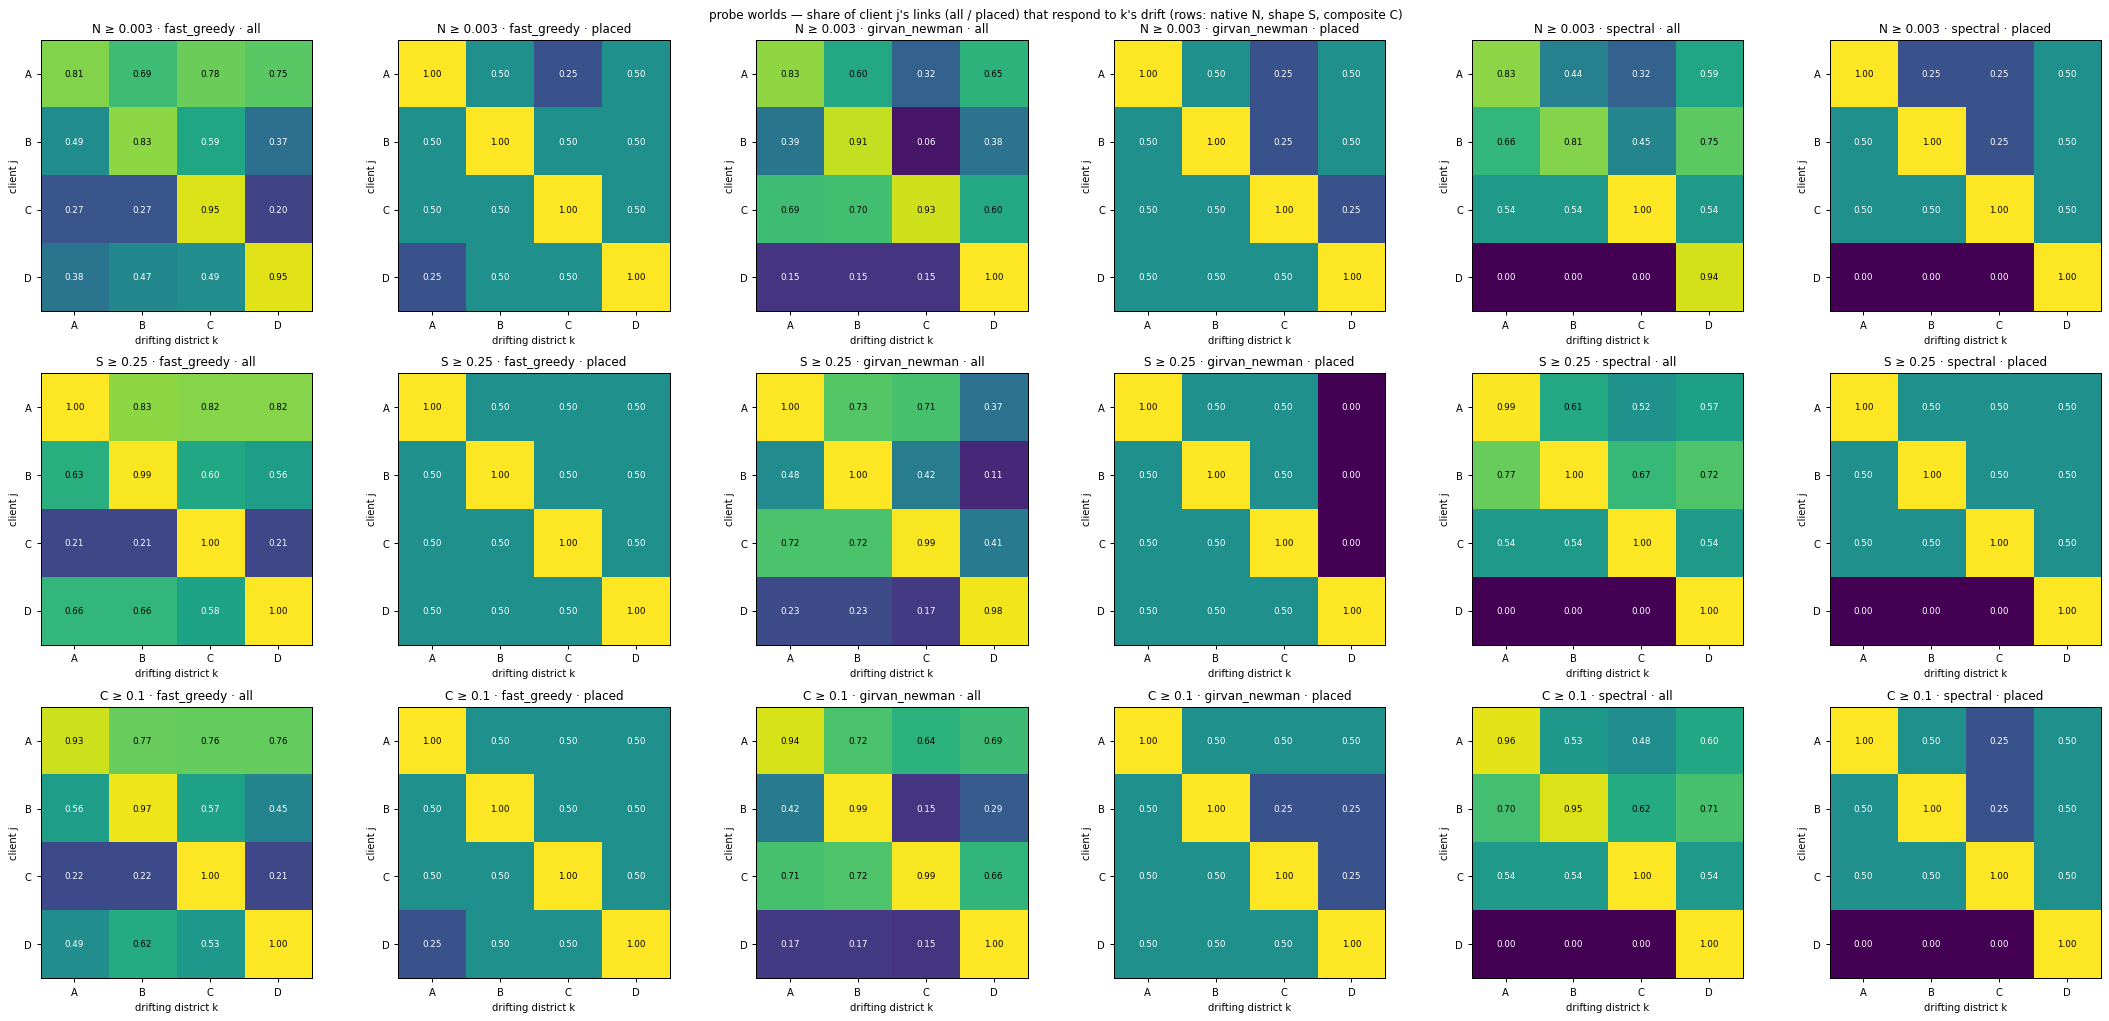

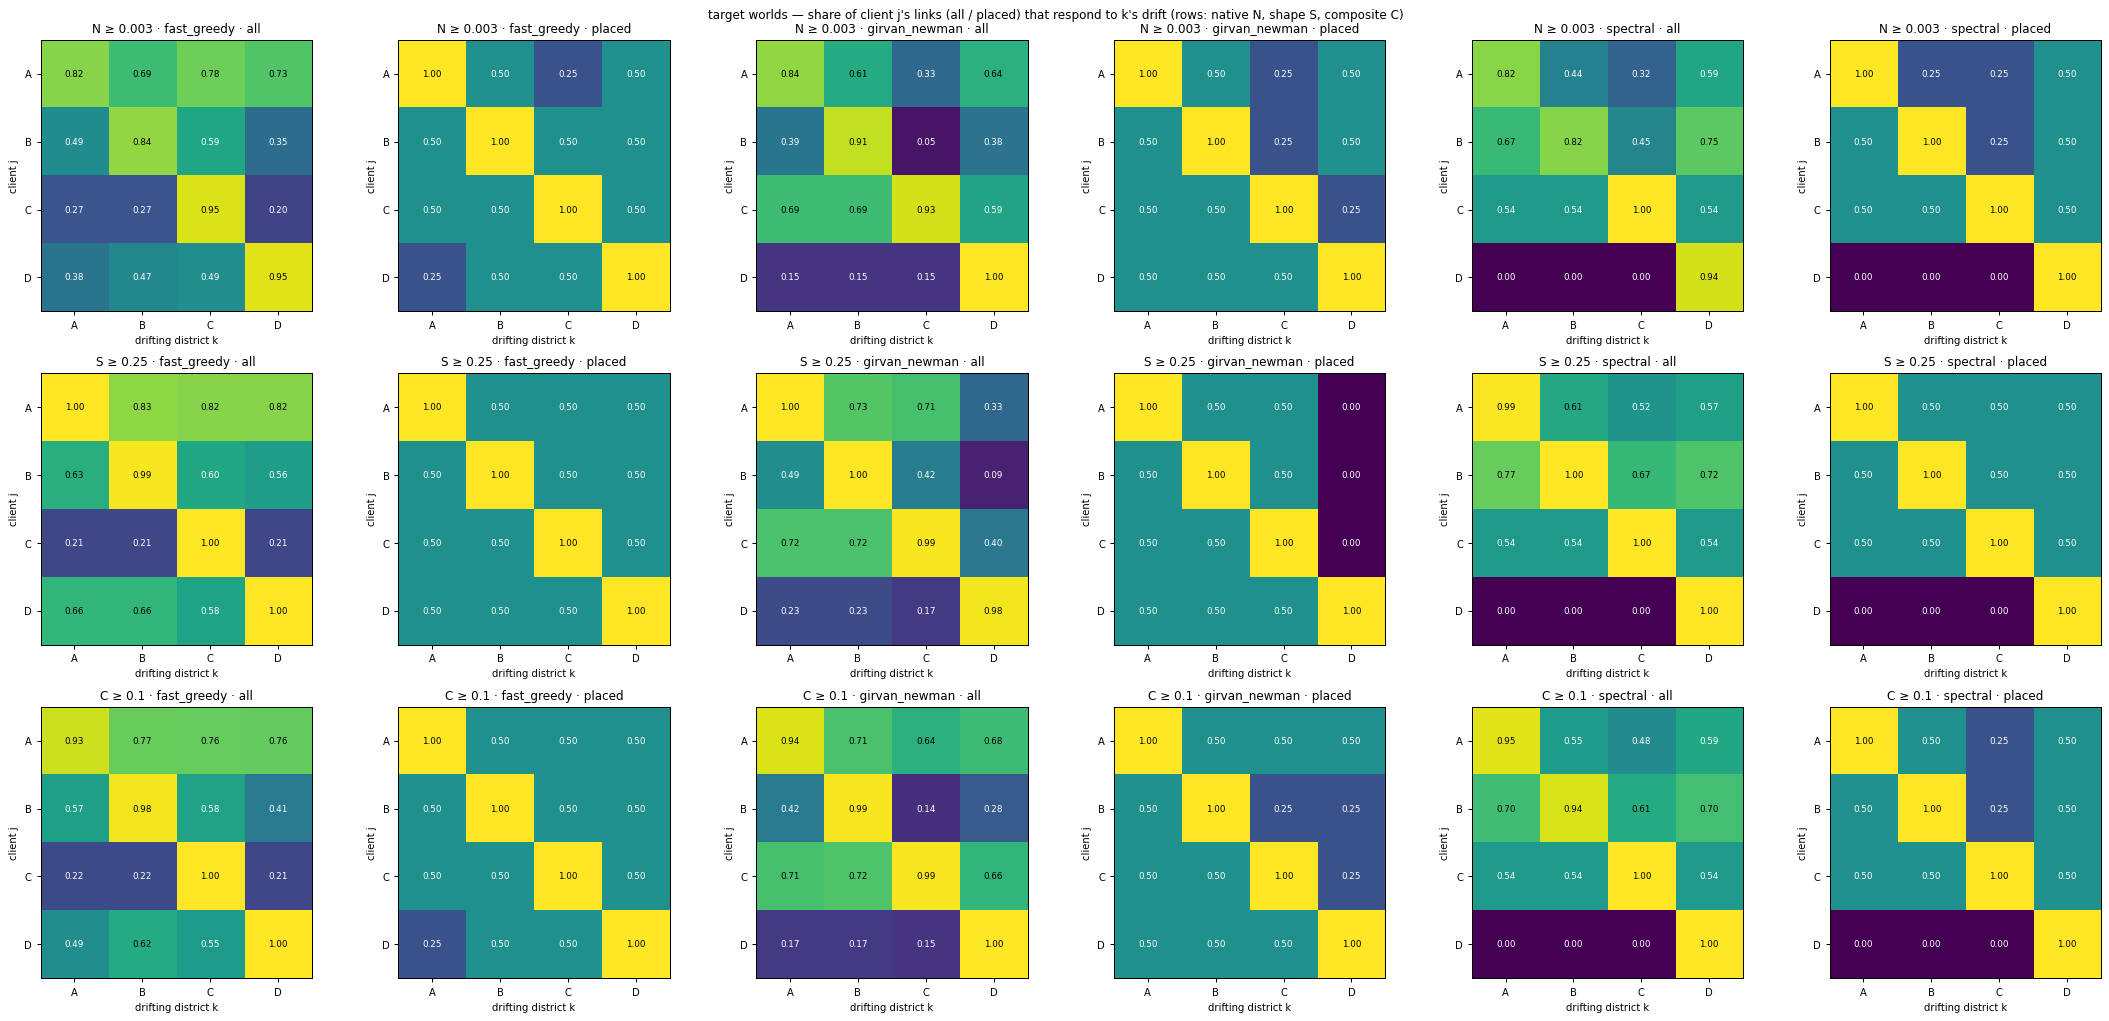

Placed-sensor matrices count 3–4 sensors per client: a cell is 0, 0.25, 0.33, 0.5, … by construction — the continuous version below shows the median metric of those sensors instead.

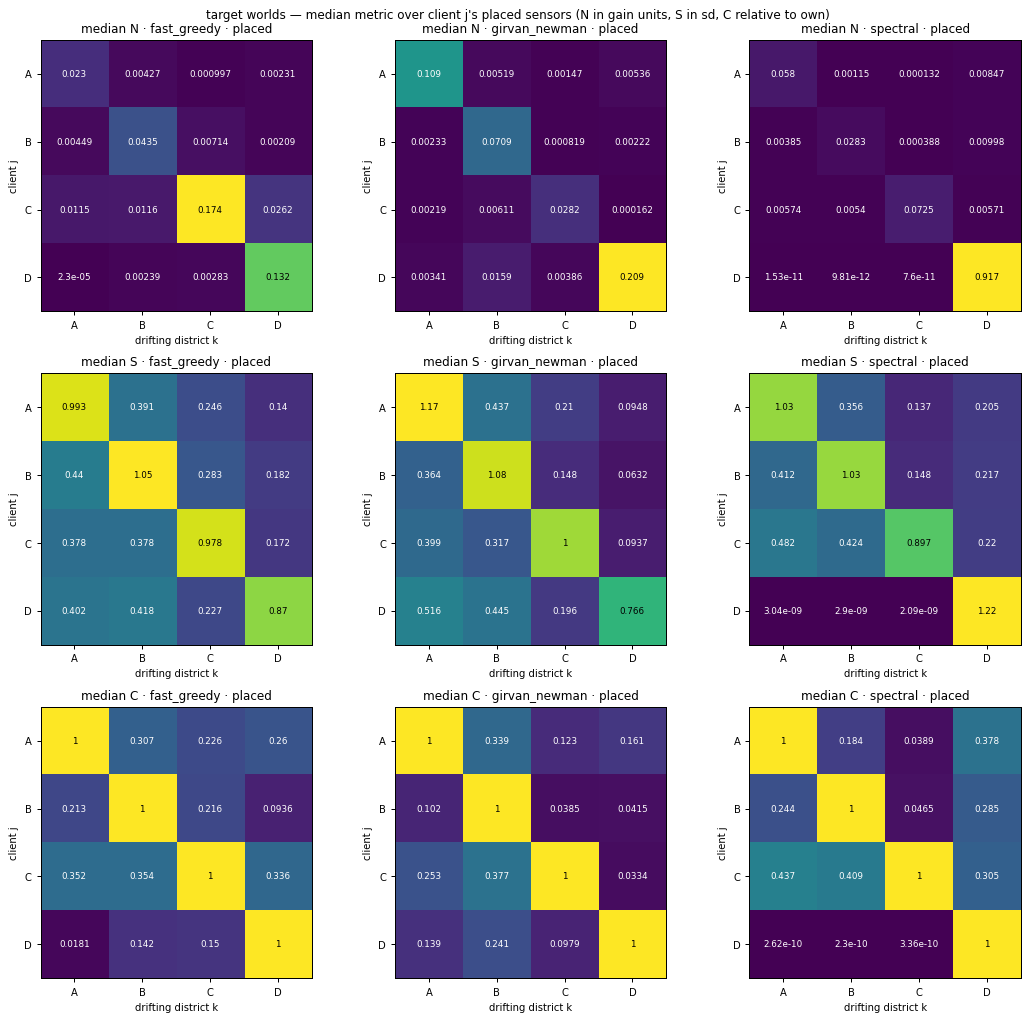

In [8]:
# A. client-pair matrices from the label metrics (final window, stored setting)
MAT = []
for (s_, m), g in LF.groupby(["set", "districting"]):
    for scope, q_ in (("all", g), ("placed", g[g["placed"]])):
        for x in ("N", "S", "C"):
            r_ = q_.assign(r=q_[x] >= FLOOR[x]).groupby(["home", "k"]).agg(
                share=("r", "mean"), n=("r", "size"), median=(x, "median")).reset_index()
            MAT.append(r_.assign(set=s_, districting=m, scope=scope, metric=x, floor=FLOOR[x]))
MAT = pd.concat(MAT, ignore_index=True).rename(columns={"home": "j"})
MAT.to_parquet(OUT / "e5_matrix.parquet", index=False)


def matrix_grid(df, value, title, vmax=1.0, fmt="{:.2f}", scopes=("all", "placed")):
    parts = sorted(df["districting"].unique())
    cols = [(m, sc) for m in parts for sc in scopes]
    fig, axes = plt.subplots(3, len(cols), figsize=(4 * len(cols), 11.5), squeeze=False)
    for i, x in enumerate(("N", "S", "C")):
        for j, (m, sc) in enumerate(cols):
            ax = axes[i, j]
            q_ = df[(df["districting"] == m) & (df["scope"] == sc) & (df["metric"] == x)]
            A = q_.pivot(index="j", columns="k", values=value)
            if not len(A):
                ax.axis("off"); continue
            V = A.to_numpy(float)
            ax.imshow(V, vmin=0, vmax=vmax if vmax else np.nanmax(V), cmap="viridis")
            ax.set_xticks(range(A.shape[1]), [c.replace("District_", "") for c in A.columns])
            ax.set_yticks(range(A.shape[0]), [c.replace("District_", "") for c in A.index])
            for (a_, b_), v in np.ndenumerate(V):
                if np.isfinite(v):
                    ax.text(b_, a_, fmt.format(v), ha="center", va="center", fontsize=7,
                            color="w" if v < 0.6 * (vmax or np.nanmax(V)) else "k")
            ax.set(xlabel="drifting district k", ylabel="client j")
            ax.set_title(f"{x} ≥ {FLOOR[x]:g} · {m} · {sc}" if value == "share" else f"median {x} · {m} · {sc}")
    fig.suptitle(title); fig.tight_layout(); plt.show()


for s_ in sorted(MAT["set"].unique()):
    matrix_grid(MAT[MAT["set"] == s_], "share",
                f"{s_} worlds — share of client j's links (all / placed) that respond to k's drift "
                "(rows: native N, shape S, composite C)")
display(Markdown("Placed-sensor matrices count 3–4 sensors per client: a cell is 0, 0.25, 0.33, 0.5, … by construction — "
                 "the continuous version below shows the median metric of those sensors instead."))
matrix_grid(MAT[MAT["set"] == "target"], "median",
            "target worlds — median metric over client j's placed sensors (N in gain units, S in sd, C relative to own)",
            vmax=None, fmt="{:.3g}", scopes=("placed",))

## S · Sensitivity to the relevance floor

Each metric swept over its floor (`SWEEP`): how many cells respond (own, other, placed, loops); whether the response is
district-specific (the share of responding links that respond to every foreign drift — a district-blind label is close
to 1); branch links that respond to a foreign drift (exactly zero by physics, so any value above 0 is an error); and,
on the target worlds, agreement with the study's significance (native: `sig_tot`, shape: `sig_shape`, composite: either).

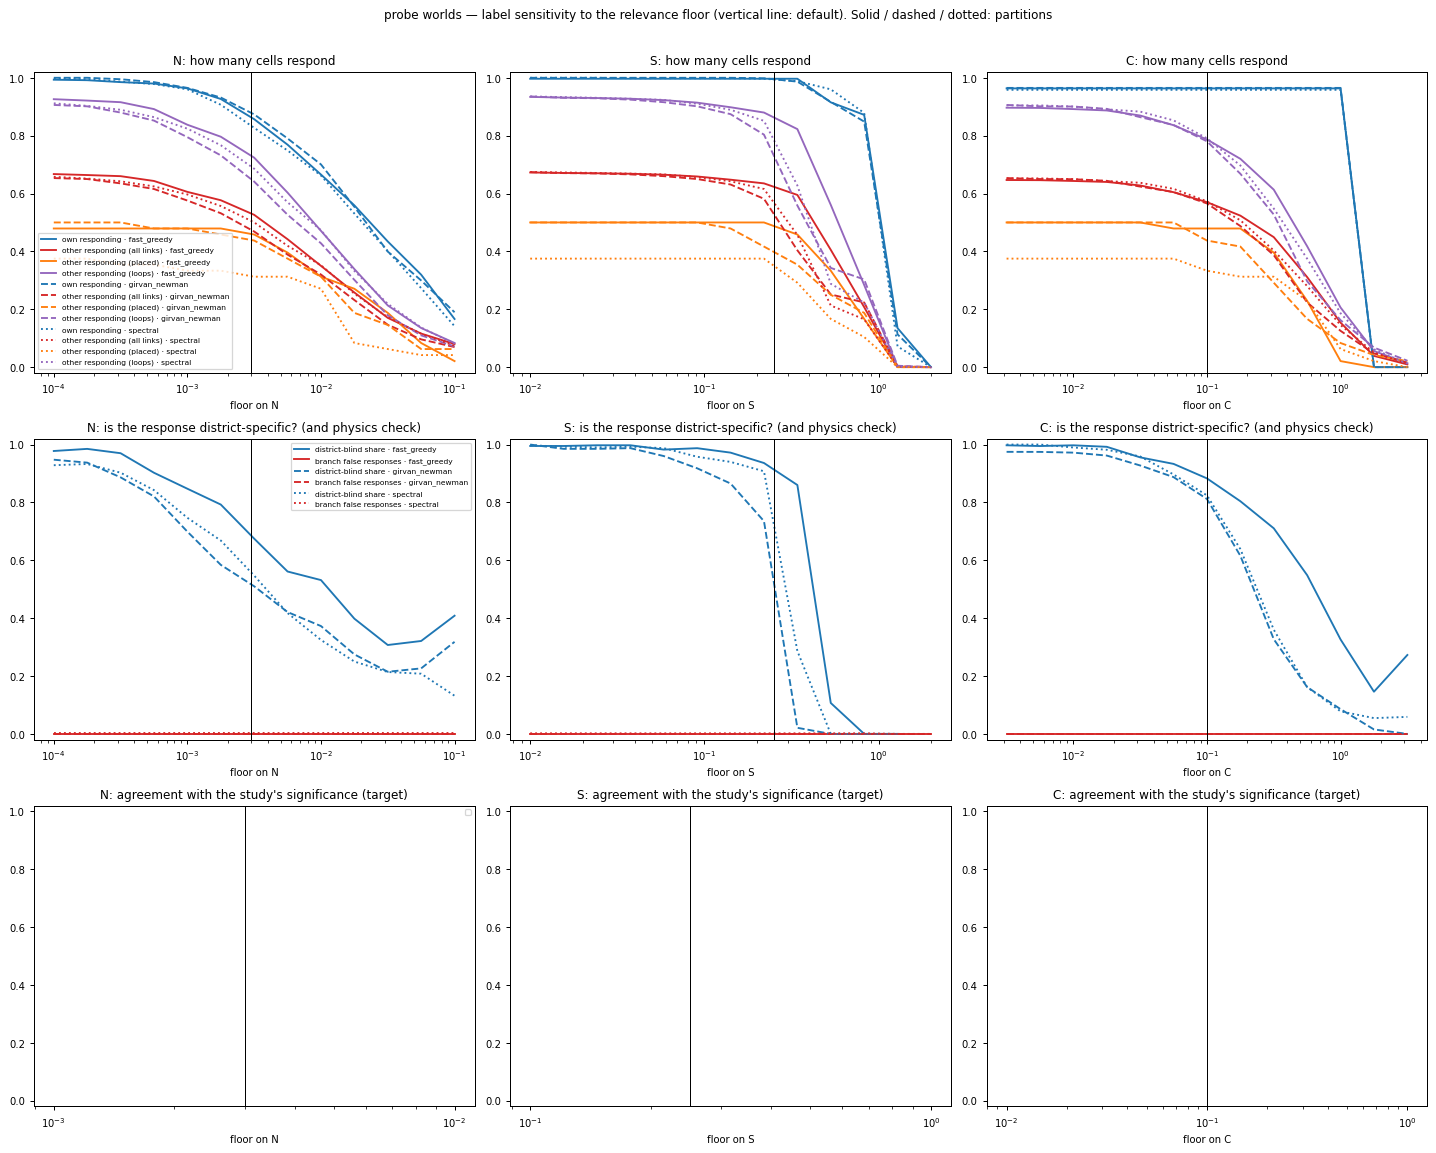

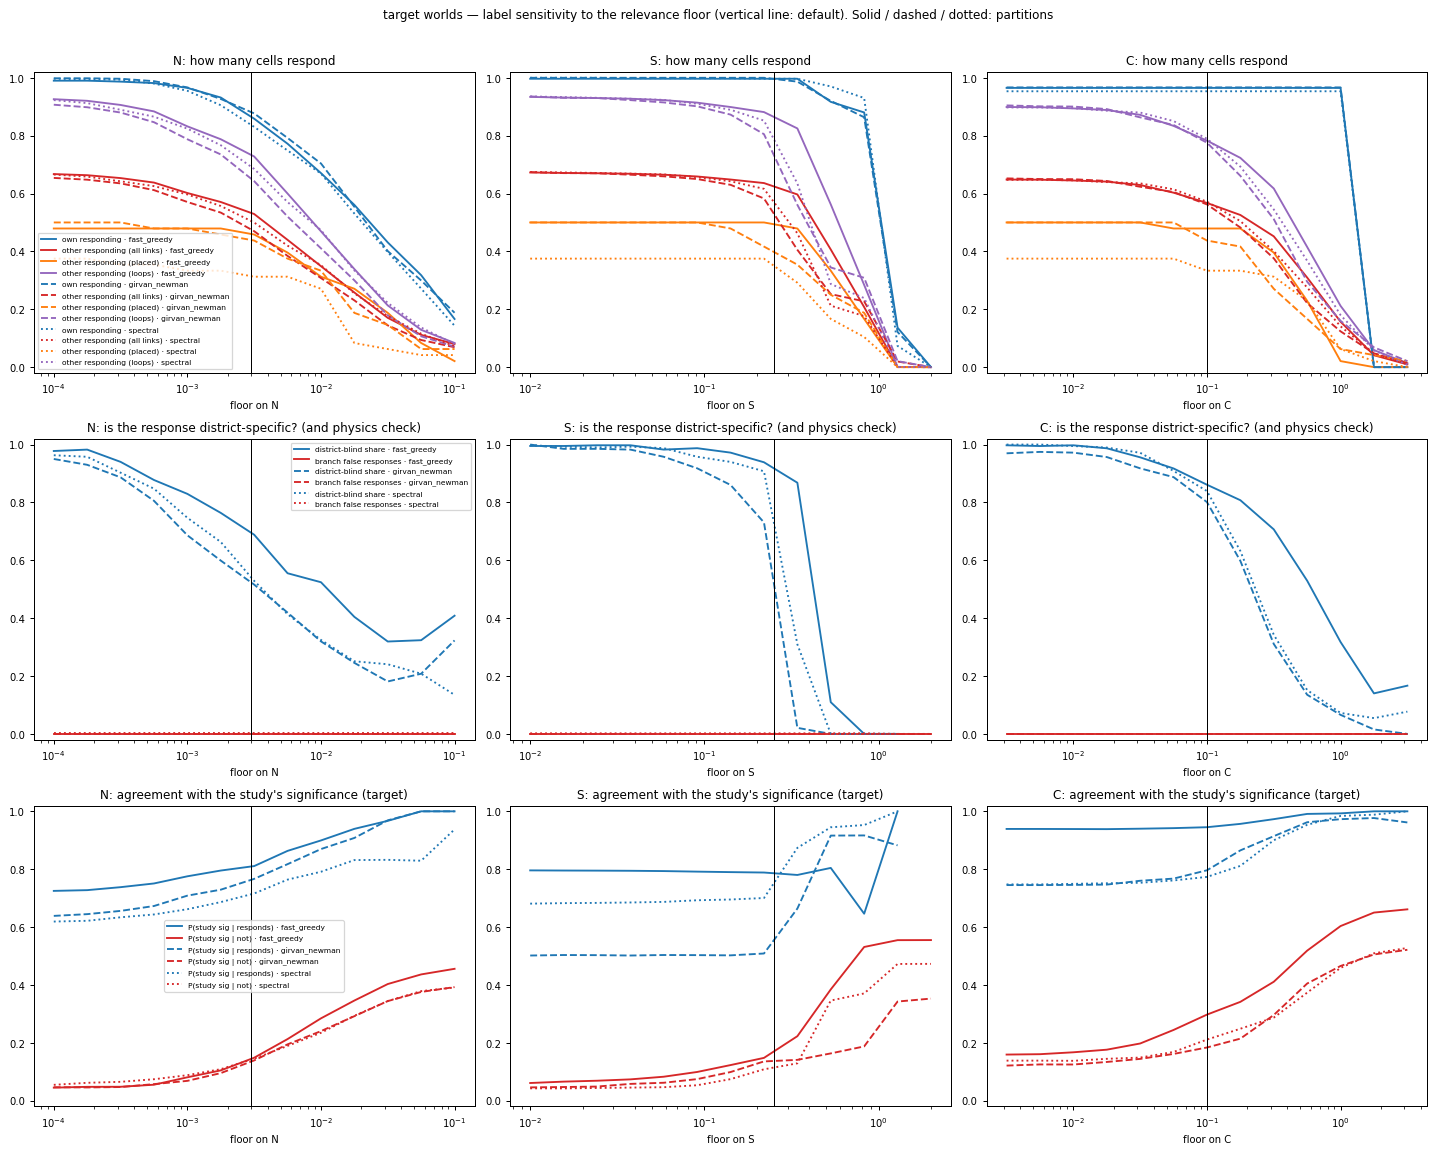

Read: a floor is defensible where the off-diagonal share is on a plateau (labels do not depend on the exact value), the district-blind share is low (the label separates districts) and branches never respond.

,set,districting,metric,eps,own responding,other responding (all links),other responding (placed),other responding (loops),district-blind share,branch false responses,P(study sig | responds),P(study sig | not)
0,target,fast_greedy,C,0.100,0.965,0.567,0.479,0.783,0.861,0.000,0.945,0.297
1,target,girvan_newman,C,0.100,0.967,0.562,0.438,0.776,0.801,0.000,0.796,0.184
2,target,spectral,C,0.100,0.953,0.572,0.333,0.789,0.839,0.000,0.773,0.211
3,target,fast_greedy,N,0.003,0.859,0.529,0.458,0.728,0.688,0.000,0.811,0.148
4,target,girvan_newman,N,0.003,0.877,0.470,0.438,0.643,0.516,0.000,0.767,0.139
5,target,spectral,N,0.003,0.830,0.500,0.312,0.685,0.529,0.002,0.716,0.145
6,target,fast_greedy,S,0.220,0.997,0.636,0.500,0.881,0.939,0.000,0.788,0.148
7,target,girvan_newman,S,0.220,1.000,0.583,0.417,0.805,0.731,0.000,0.509,0.136
8,target,spectral,S,0.220,0.997,0.616,0.375,0.852,0.908,0.002,0.700,0.108


In [9]:
# S. sensitivity of the labels to the relevance floor
se_ = SE.assign(element=SE["element"].astype(str)).rename(columns={"drift": "k"})[
    ["districting", "k", "element", "sig_tot", "sig_shape"]]
SW = LF.merge(se_, on=["districting", "k", "element"], how="left")
study_flag = {"N": SW["sig_tot"], "S": SW["sig_shape"],
              "C": SW["sig_tot"].astype("boolean") | SW["sig_shape"].astype("boolean")}
rows = []
for x in ("N", "S", "C"):
    SW["_sig"] = study_flag[x]
    for (s_, m), g in SW.groupby(["set", "districting"]):
        off, on = g[~g["own"]], g[g["own"]]
        for eps in SWEEP[x]:
            r_off = off[x] >= eps
            per_link = off.assign(r=r_off).groupby("element").agg(n_resp=("r", "sum"), n=("r", "size"))
            anyk = per_link["n_resp"] > 0
            row = {"set": s_, "districting": m, "metric": x, "eps": eps,
                   "own responding": float((on[x] >= eps).mean()),
                   "other responding (all links)": float(r_off.mean()),
                   "other responding (placed)": float(r_off[off["placed"]].mean()) if off["placed"].any() else np.nan,
                   "other responding (loops)": float(r_off[off["topo"] == "loop"].mean()),
                   "district-blind share": float((per_link["n_resp"] == per_link["n"])[anyk].mean()) if anyk.any() else np.nan,
                   "branch false responses": float(r_off[off["topo"] == "branch"].mean())}
            if s_ == "target":
                sg = off["_sig"].astype("boolean")
                ok = sg.notna()
                row["P(study sig | responds)"] = float(sg[ok & r_off].mean()) if (ok & r_off).any() else np.nan
                row["P(study sig | not)"] = float(sg[ok & ~r_off].mean()) if (ok & ~r_off).any() else np.nan
            rows.append(row)
SENS = pd.DataFrame(rows)
SENS.to_parquet(OUT / "e5_sensitivity.parquet", index=False)

panels = [("own responding", "other responding (all links)", "other responding (placed)", "other responding (loops)"),
          ("district-blind share", "branch false responses"),
          ("P(study sig | responds)", "P(study sig | not)")]
ptitle = ["how many cells respond", "is the response district-specific? (and physics check)",
          "agreement with the study's significance (target)"]
for s_ in sorted(SENS["set"].unique()):
    fig, axes = plt.subplots(3, 3, figsize=(16, 13), squeeze=False)
    for j, x in enumerate(("N", "S", "C")):
        for i, cols in enumerate(panels):
            ax = axes[i, j]
            for (m, q_), ls in zip(SENS[(SENS["set"] == s_) & (SENS["metric"] == x)].groupby("districting"),
                                   ("-", "--", ":")):
                for c, cc in zip(cols, ("#1f77b4", "#d62728", "#ff7f0e", "#9467bd")):
                    if c in q_ and q_[c].notna().any():
                        ax.plot(q_["eps"], q_[c], ls=ls, color=cc, label=f"{c} · {m}")
            ax.axvline(FLOOR[x], color="k", lw=0.8)
            ax.set(xscale="log", ylim=(-0.02, 1.02), xlabel=f"floor on {x}",
                   title=f"{x}: {ptitle[i]}")
            if j == 0:
                ax.legend(fontsize=6)
    fig.suptitle(f"{s_} worlds — label sensitivity to the relevance floor (vertical line: default). "
                 "Solid / dashed / dotted: partitions")
    fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()
display(Markdown("Read: a floor is defensible where the off-diagonal share is on a plateau (labels do not depend on the "
                 "exact value), the district-blind share is low (the label separates districts) and branches never respond."))
display(SENS[SENS["set"] == "target"].groupby(["metric", "districting"]).apply(
    lambda q: q.iloc[(q["eps"] - FLOOR[q.name[0]]).abs().argsort()[:1]]).reset_index(drop=True).round(3))

## P · Sanity: what the numbers mean in the pipes

Population view first: how proportional ($r^2_t$) and how systematic each response is, and every off-diagonal cell in
the N–S plane coloured by its systematic share. Then **sensor cards**: for one sensor and one drifting district, a week
of hourly flow with and without the drift; the exact effect against its proportional part $g\,\Delta D_k$; which pumps
switch differently; the hour-by-hour relation; the native weekly profile (mean and spread over weeks); the z-scored
profile a client sees; the label month by month across init / transition / final; and the numbers. The gallery picks
six placed sensors of the first partition by their numbers (own branch, own loop, strongest composite, native-only,
shape-only, large hourly change with no label); the widget below opens any placed sensor.

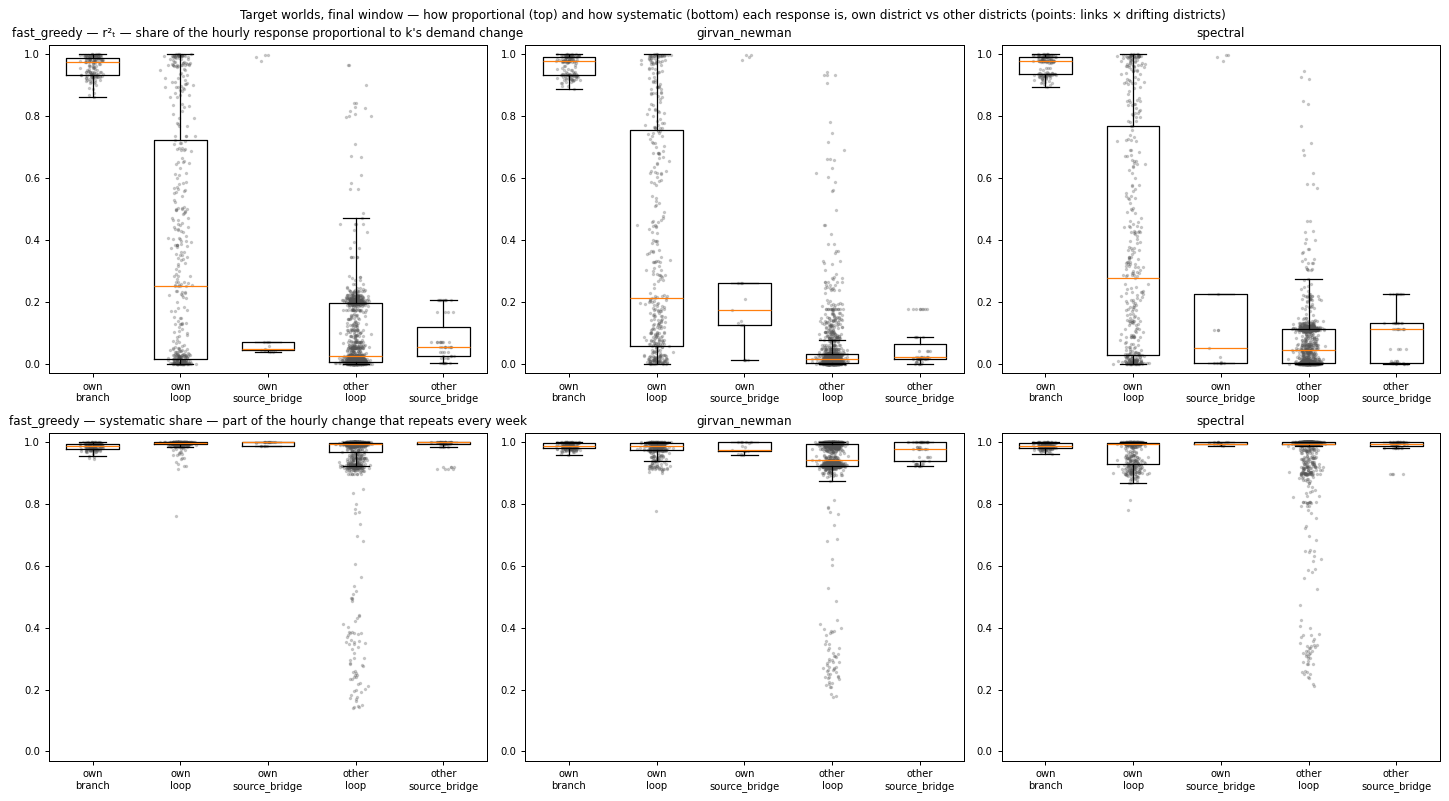

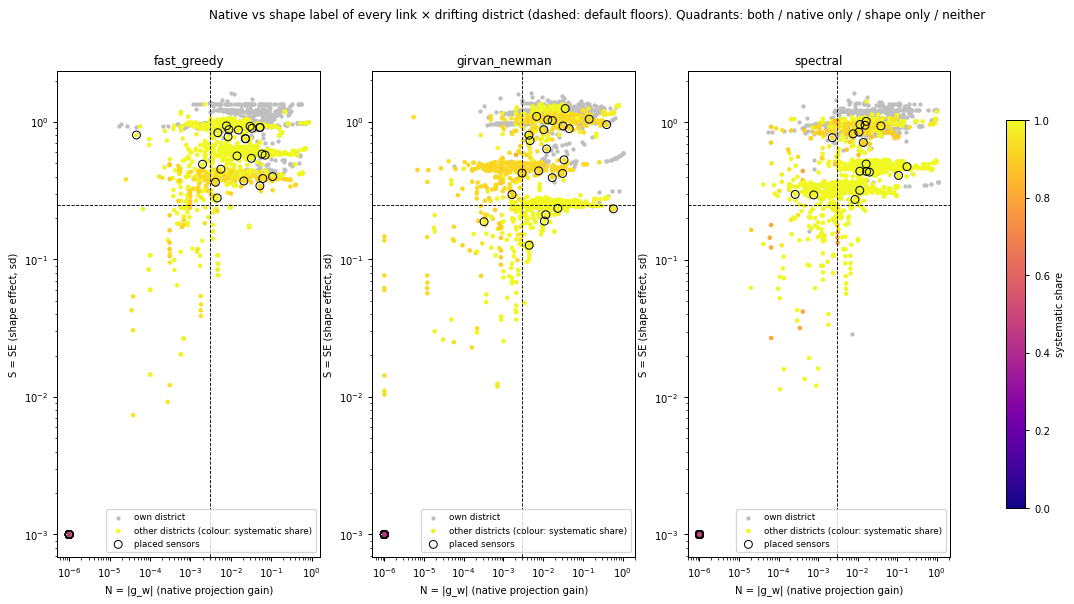

#### own district, branch: exact and proportional

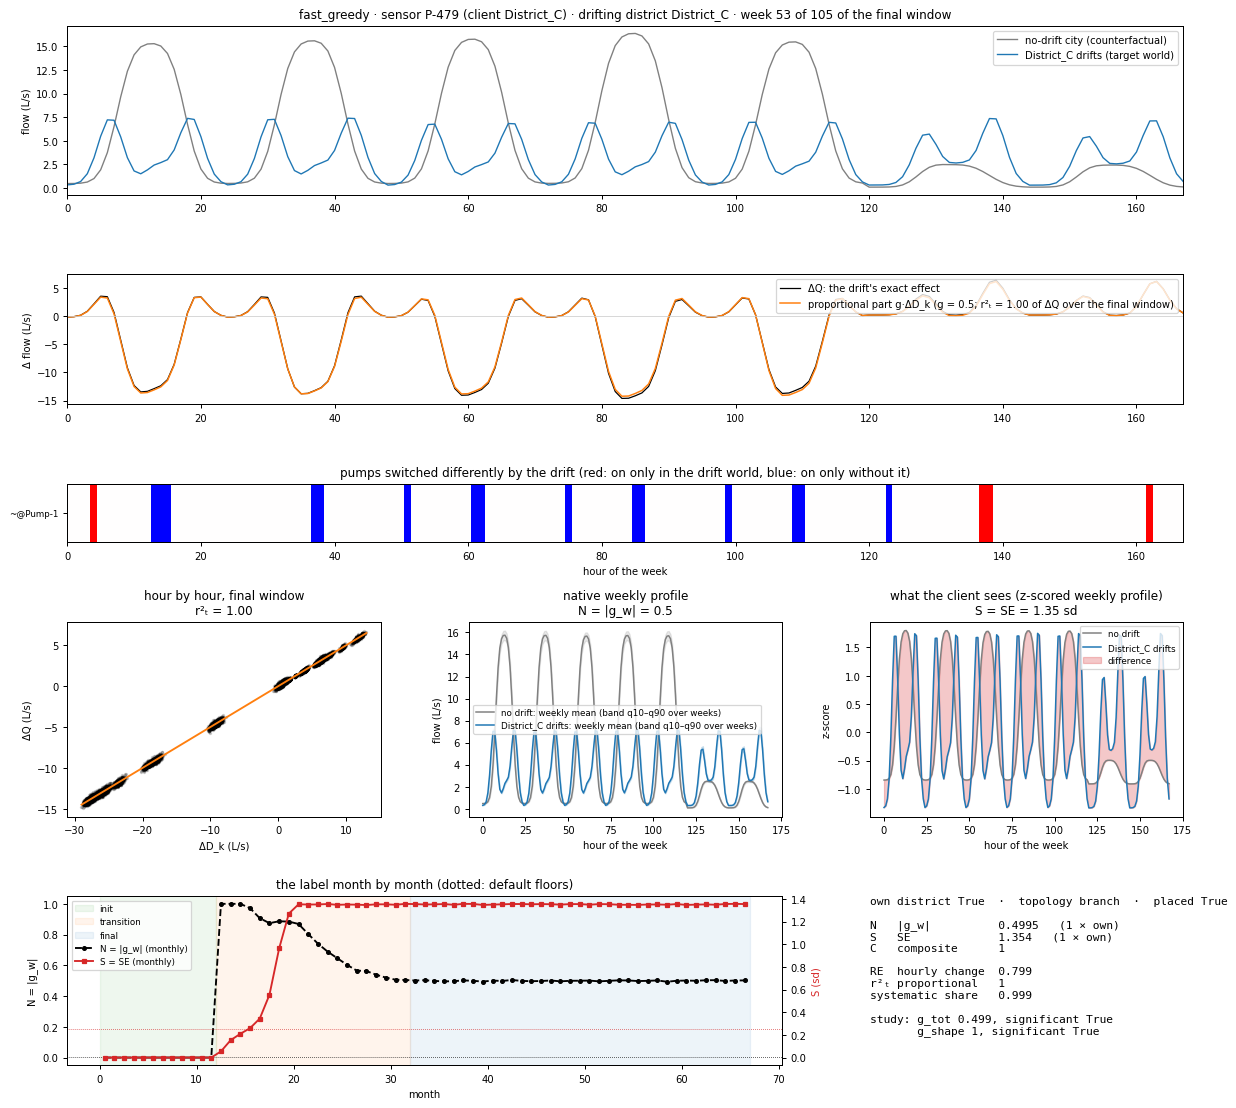

#### own district, loop / source bridge

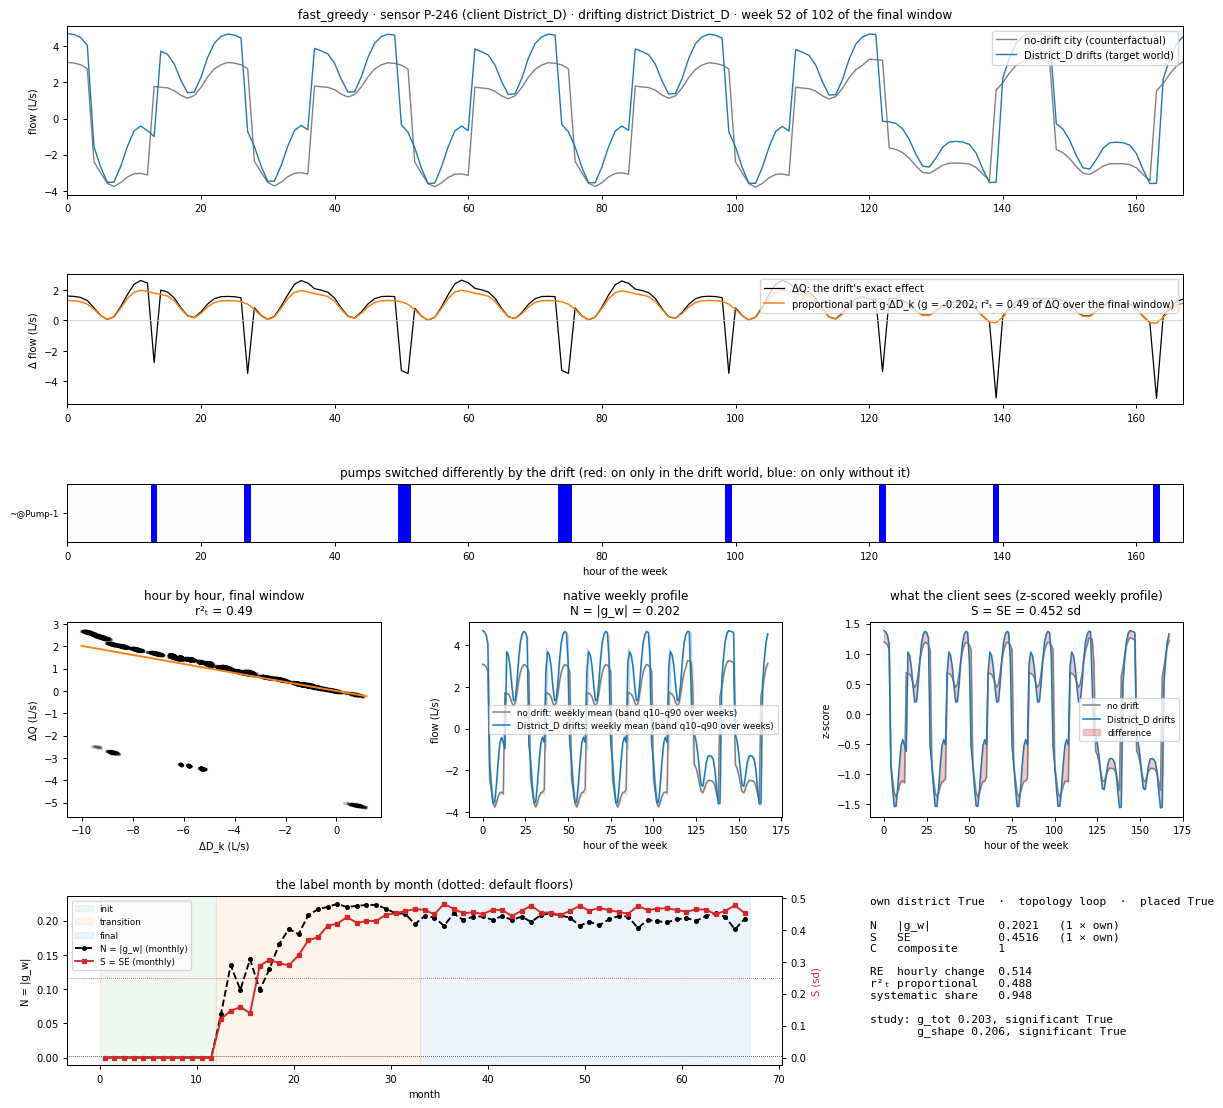

#### other district: strongest composite

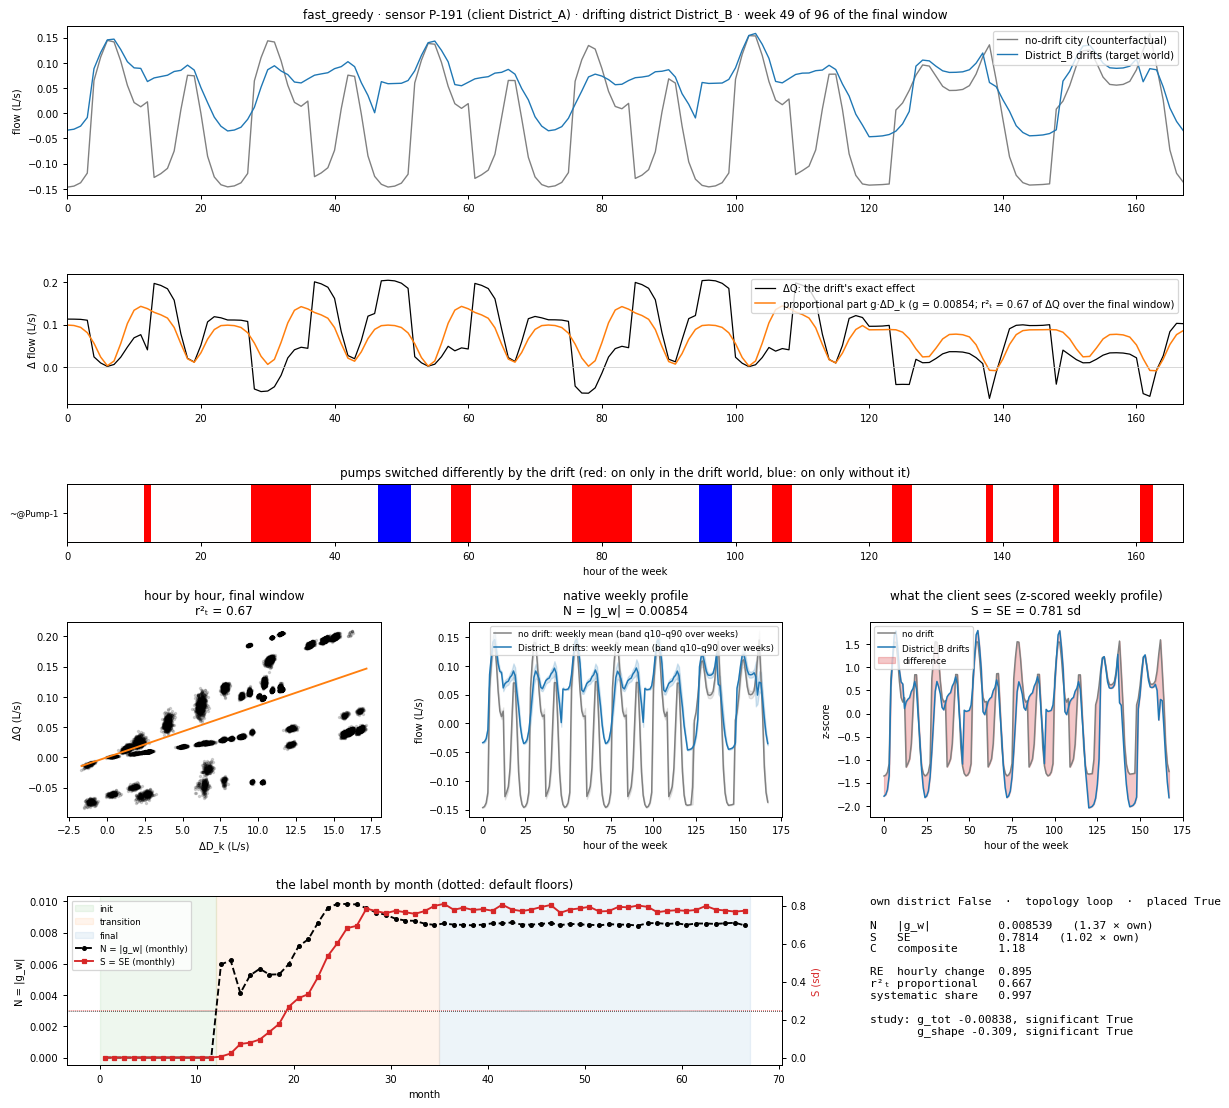

#### other district: shape only

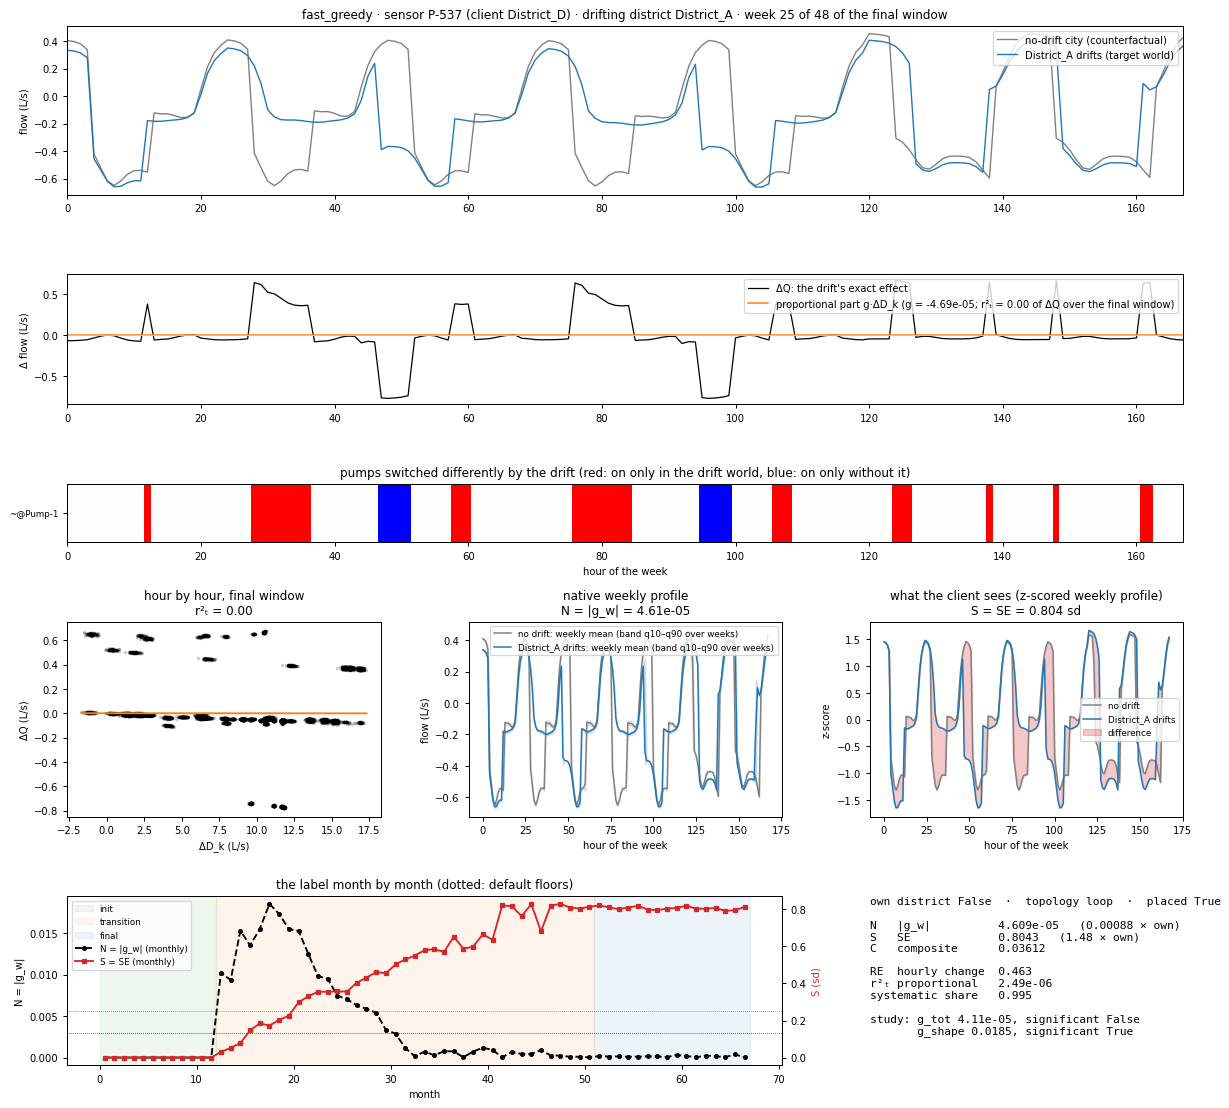

#### other district: large hourly change, no label (switching reshuffle)

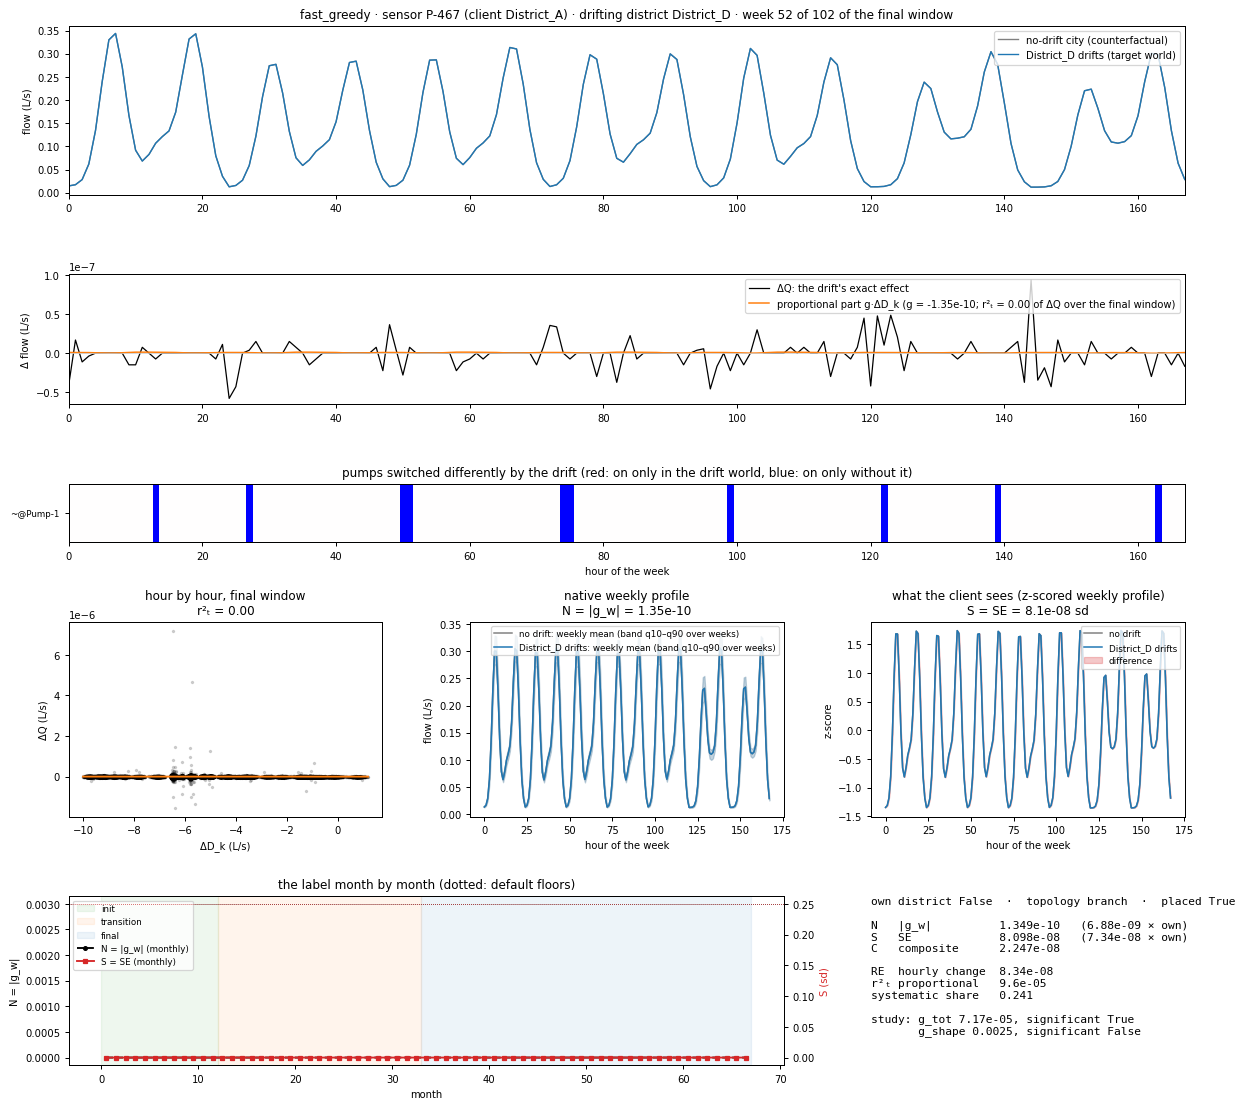

In [10]:
# P. sanity: how the numbers relate to what actually happens in the pipes
TF = LF[LF["set"] == "target"].copy()
TF["group"] = np.where(TF["own"], "own · ", "other · ") + TF["topo"]
order = [g for g in ("own · branch", "own · loop", "own · source_bridge", "other · loop", "other · source_bridge")
         if g in set(TF["group"])]
parts = sorted(TF["districting"].unique())
fig, axes = plt.subplots(2, len(parts), figsize=(16, 9), squeeze=False)
for j, m in enumerate(parts):
    q_ = TF[TF["districting"] == m]
    for i, (col, lab) in enumerate((("r2_t", "r²ₜ — share of the hourly response proportional to k's demand change"),
                                    ("sys_share", "systematic share — part of the hourly change that repeats every week"))):
        ax = axes[i, j]
        data = [q_[q_["group"] == g][col].dropna().clip(0, 1) for g in order]
        ax.boxplot(data, widths=0.6, showfliers=False)
        for x_, d_ in enumerate(data, start=1):
            ax.scatter(np.random.default_rng(0).normal(x_, 0.06, len(d_)), d_, s=3, alpha=0.25, color="#555")
        ax.set_xticks(range(1, len(order) + 1), [o.replace(" · ", "\n") for o in order])
        ax.set(ylim=(-0.03, 1.03), title=f"{m} — {lab}" if j == 0 else m)
fig.suptitle("Target worlds, final window — how proportional (top) and how systematic (bottom) each response is, "
             "own district vs other districts (points: links × drifting districts)")
fig.tight_layout(); plt.show()

fig, axes = plt.subplots(1, len(parts), figsize=(16, 7), squeeze=False)
for j, m in enumerate(parts):
    ax = axes[0, j]
    q_ = TF[TF["districting"] == m]
    o_ = q_[q_["own"]]
    ax.scatter(o_["N"].clip(1e-6), o_["S"].clip(1e-3), s=6, color="0.75", label="own district")
    x_ = q_[~q_["own"]]
    sc = ax.scatter(x_["N"].clip(1e-6), x_["S"].clip(1e-3), s=7, c=x_["sys_share"].clip(0, 1), cmap="plasma",
                    vmin=0, vmax=1, label="other districts (colour: systematic share)")
    pl = x_[x_["placed"]]
    ax.scatter(pl["N"].clip(1e-6), pl["S"].clip(1e-3), s=40, facecolors="none", edgecolors="k", lw=0.8,
               label="placed sensors")
    ax.axvline(FLOOR["N"], color="k", lw=0.7, ls="--"); ax.axhline(FLOOR["S"], color="k", lw=0.7, ls="--")
    ax.set(xscale="log", yscale="log", xlabel="N = |g_w| (native projection gain)", ylabel="S = SE (shape effect, sd)",
           title=m)
    ax.legend(fontsize=7, loc="lower right")
fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.8, label="systematic share")
fig.suptitle("Native vs shape label of every link × drifting district (dashed: default floors). Quadrants: both / "
             "native only / shape only / neither")
plt.show()


# ---- sensor cards --------------------------------------------------------------------------------
_SER = {}


def _series(m, k):
    for key in (f"{m}__nodrift", f"{m}__{k}"):
        if key not in _SER:
            _SER[key] = dict(np.load(SERIES / f"{key}.npz", allow_pickle=False))
    return _SER[f"{m}__nodrift"], _SER[f"{m}__{k}"]


def sensor_card(m, k, element, week=None):
    """Everything one label summarises, for one sensor and one drifting district (target world, stored setting)."""
    n0, n1 = _series(m, k)
    links = list(n1["links"])
    if element not in links:
        print(f"{element}: no saved series (only placed sensors are saved)"); return
    j = links.index(element)
    i0, i1, f0, f1 = map(int, n1["periods"])
    sd, sm = int(n1["sd"]), int(n1["sm"])
    Q0, Q1 = n0["Q"][:, j].astype(float), n1["Q"][:, j].astype(float)
    D0k, D1k = n0[f"D_{k}"].astype(float), n1["D"].astype(float)
    dQ, dD = Q1 - Q0, D1k - D0k
    W = slice(f0, f1)
    g_h = float(dQ[W] @ dD[W] / (dD[W] @ dD[W]))
    r2 = 1 - float(((dQ[W] - g_h * dD[W]) ** 2).sum() / max((dQ[W] ** 2).sum(), 1e-18))
    lab = LB[(LB["set"] == "target") & (LB["districting"] == m) & (LB["k"] == k) & (LB["element"] == element)
             & (LB["step"] == 3600) & (LB["output"] == "snap") & (LB["period"] == "final")]
    row = lab.iloc[0] if len(lab) else None
    nweeks = (f1 - f0) // (7 * sd)
    wk = nweeks // 2 if week is None else int(np.clip(week, 0, nweeks - 1))
    a = f0 + wk * 7 * sd
    t = np.arange(7 * sd)

    fig = plt.figure(figsize=(16, 15))
    gs = fig.add_gridspec(5, 3, height_ratios=[1.3, 1.0, 0.45, 1.5, 1.3], hspace=0.55, wspace=0.28)
    ax = fig.add_subplot(gs[0, :])
    ax.plot(t, Q0[a:a + 7 * sd], color="0.5", lw=1.1, label="no-drift city (counterfactual)")
    ax.plot(t, Q1[a:a + 7 * sd], color="#1f77b4", lw=1.1, label=f"{k} drifts (target world)")
    ax.set(ylabel="flow (L/s)", xlim=(0, 7 * sd - 1),
           title=f"{m} · sensor {element} (client {row['home'] if row is not None else '?'}) · drifting district {k} · "
                 f"week {wk + 1} of {nweeks} of the final window")
    ax.legend(fontsize=8, loc="upper right")
    ax = fig.add_subplot(gs[1, :], sharex=ax)
    ax.plot(t, dQ[a:a + 7 * sd], color="k", lw=1.0, label="ΔQ: the drift's exact effect")
    ax.plot(t, g_h * dD[a:a + 7 * sd], color="#ff7f0e", lw=1.2,
            label=f"proportional part g·ΔD_k (g = {g_h:.3g}; r²ₜ = {r2:.2f} of ΔQ over the final window)")
    ax.axhline(0, color="0.8", lw=0.6)
    ax.set(ylabel="Δ flow (L/s)"); ax.legend(fontsize=8, loc="upper right")
    ax = fig.add_subplot(gs[2, :], sharex=ax)
    dU = (n1["U"][a:a + 7 * sd].astype(int) - n0["U"][a:a + 7 * sd].astype(int)).T
    pumps = list(n1["pumps"])
    busy = np.abs(dU).sum(axis=1) > 0
    if busy.any():
        ax.imshow(dU[busy], aspect="auto", cmap="bwr", vmin=-1, vmax=1, interpolation="nearest",
                  extent=(-0.5, 7 * sd - 0.5, busy.sum() - 0.5, -0.5))
        ax.set_yticks(range(busy.sum()), [p for p, b in zip(pumps, busy) if b], fontsize=7)
    ax.set(xlabel="hour of the week", title="pumps switched differently by the drift (red: on only in the drift world, "
                                             "blue: on only without it)")

    P0, P1 = profile(Q0[W], sd, f0)[0], profile(Q1[W], sd, f0)[0]
    stack0 = np.stack([Q0[f0 + w * 7 * sd: f0 + (w + 1) * 7 * sd] for w in range(nweeks)])
    stack1 = np.stack([Q1[f0 + w * 7 * sd: f0 + (w + 1) * 7 * sd] for w in range(nweeks)])
    ax = fig.add_subplot(gs[3, 0])
    ax.scatter(dD[W], dQ[W], s=3, alpha=0.15, color="k", rasterized=True)
    xx = np.linspace(dD[W].min(), dD[W].max(), 10)
    ax.plot(xx, g_h * xx, color="#ff7f0e", lw=1.5)
    ax.set(xlabel="ΔD_k (L/s)", ylabel="ΔQ (L/s)", title=f"hour by hour, final window\nr²ₜ = {r2:.2f}")
    ax = fig.add_subplot(gs[3, 1])
    tt = np.arange(stack0.shape[1])
    for st, P, c, l in ((stack0, P0, "0.5", "no drift"), (stack1, P1, "#1f77b4", f"{k} drifts")):
        ax.fill_between(tt, np.quantile(st, 0.1, axis=0), np.quantile(st, 0.9, axis=0), color=c, alpha=0.18)
        ax.plot(tt, P, color=c, lw=1.2, label=f"{l}: weekly mean (band q10–q90 over weeks)")
    ax.set(xlabel="hour of the week", ylabel="flow (L/s)",
           title=f"native weekly profile\nN = |g_w| = {row['N']:.3g}" if row is not None else "native weekly profile")
    ax.legend(fontsize=7)
    ax = fig.add_subplot(gs[3, 2])
    z0, z1 = zrows(P0[None])[0], zrows(P1[None])[0]
    ax.plot(tt, z0, color="0.5", lw=1.2, label="no drift"); ax.plot(tt, z1, color="#1f77b4", lw=1.2, label=f"{k} drifts")
    ax.fill_between(tt, z0, z1, color="#d62728", alpha=0.25, label="difference")
    ax.set(xlabel="hour of the week", ylabel="z-score",
           title=f"what the client sees (z-scored weekly profile)\nS = SE = {row['S']:.3g} sd" if row is not None else "")
    ax.legend(fontsize=7)

    ax = fig.add_subplot(gs[4, :2])
    mo = E5M[(E5M["districting"] == m) & (E5M["k"] == k) & (E5M["element"] == element)].sort_values("month")
    ax.axvspan(i0 / sm, i1 / sm, color="#2ca02c", alpha=0.08, label="init")
    ax.axvspan(i1 / sm, f0 / sm, color="#ff7f0e", alpha=0.08, label="transition")
    ax.axvspan(f0 / sm, f1 / sm, color="#1f77b4", alpha=0.08, label="final")
    ax.plot(mo["month"] + 0.5, mo["g_w"].abs(), color="k", ls="--", marker="o", ms=3, label="N = |g_w| (monthly)")
    ax.axhline(FLOOR["N"], color="k", lw=0.6, ls=":")
    ax.set(xlabel="month", ylabel="N = |g_w|", title="the label month by month (dotted: default floors)")
    ax2 = ax.twinx()
    ax2.plot(mo["month"] + 0.5, mo["SE"], color="#d62728", marker="s", ms=3, label="S = SE (monthly)")
    ax2.axhline(FLOOR["S"], color="#d62728", lw=0.6, ls=":")
    ax2.set_ylabel("S (sd)", color="#d62728")
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=7, loc="upper left")
    ax = fig.add_subplot(gs[4, 2]); ax.axis("off")
    if row is not None:
        st_ = SE[(SE["districting"] == m) & (SE["drift"] == k) & (SE["element"].astype(str) == element)]
        txt = [f"own district {row['own']}  ·  topology {row['topo']}  ·  placed {row['placed']}", "",
               f"N   |g_w|          {row['N']:.4g}   ({row['N_rel']:.3g} × own)" if np.isfinite(row["N_rel"]) else f"N   |g_w|          {row['N']:.4g}",
               f"S   SE             {row['S']:.4g}   ({row['S_rel']:.3g} × own)" if np.isfinite(row["S_rel"]) else f"S   SE             {row['S']:.4g}",
               f"C   composite      {row['C']:.4g}" if np.isfinite(row["C"]) else "C   composite      —", "",
               f"RE  hourly change  {row['RE']:.3g}", f"r²ₜ proportional   {row['r2_t']:.3g}",
               f"systematic share   {row['sys_share']:.3g}"]
        if len(st_):
            txt += ["", f"study: g_tot {st_['g_tot'].iloc[0]:.3g}, significant {bool(st_['sig_tot'].iloc[0])}",
                    f"       g_shape {st_['g_shape'].iloc[0]:.3g}, significant {bool(st_['sig_shape'].iloc[0])}"]
        ax.text(0, 1, "\n".join(txt), va="top", family="monospace", fontsize=9)
    plt.show()


def gallery(m):
    """Six sensors chosen by their numbers, to show what each kind of label looks like in the pipes."""
    q_ = LF[(LF["set"] == "target") & (LF["districting"] == m) & LF["placed"]]
    o_, x_ = q_[q_["own"]], q_[~q_["own"]]
    picks = []

    def pick(df, by, asc, why):
        if len(df):
            r = df.sort_values(by, ascending=asc).iloc[0]
            picks.append((r["k"], r["element"], why))
    pick(o_[o_["topo"] == "branch"], "N", False, "own district, branch: exact and proportional")
    pick(o_[o_["topo"] != "branch"], "N", False, "own district, loop / source bridge")
    pick(x_, "C", False, "other district: strongest composite")
    pick(x_[(x_["N"] >= FLOOR["N"]) & (x_["S"] < FLOOR["S"])], "N", False, "other district: native only")
    pick(x_[(x_["S"] >= FLOOR["S"]) & (x_["N"] < FLOOR["N"])], "S", False, "other district: shape only")
    pick(x_[(x_["N"] < FLOOR["N"]) & (x_["S"] < FLOOR["S"])], "RE", False,
         "other district: large hourly change, no label (switching reshuffle)")
    for k, e, why in picks:
        display(Markdown(f"#### {why}"))
        sensor_card(m, k, e)


if SAVE_SERIES and len(LF[LF["set"] == "target"]):
    m0 = sorted(LF[LF["set"] == "target"]["districting"].unique())[0]
    gallery(m0)

In [11]:
# interactive sensor cards (any partition, drifting district, placed sensor, week)
if SAVE_SERIES and len(LF[LF["set"] == "target"]):
    _pl = LF[(LF["set"] == "target") & LF["placed"]]
    w_m = ipw.Dropdown(options=sorted(_pl["districting"].unique()), description="partition")
    w_k = ipw.Dropdown(options=sorted(_pl["k"].unique()), description="drifting k")
    w_s = ipw.Dropdown(description="sensor")
    w_w = ipw.IntSlider(value=0, min=0, max=40, description="week")

    def _sensors(*_):
        q_ = _pl[_pl["districting"] == w_m.value].drop_duplicates("element").sort_values(["home", "element"])
        w_s.options = [(f"{h.replace('District_', '')} · {e}", e) for h, e in zip(q_["home"], q_["element"])]
        if w_s.options:
            w_s.value = w_s.options[0][1]
    w_m.observe(_sensors, "value"); _sensors()
    out = ipw.interactive_output(lambda m, k, s, w: sensor_card(m, k, s, w),
                                 {"m": w_m, "k": w_k, "s": w_s, "w": w_w})
    display(ipw.VBox([ipw.HBox([w_m, w_k, w_s, w_w]), out]))

## L · The target labels

For every partition: the placed sensors (rows: client · slot · link) × drifting district, per metric (rows) and period
(columns). Init is exactly zero by construction; transition and final show how the dependence settles. Then the shape
and native labels month by month for every drifting district.

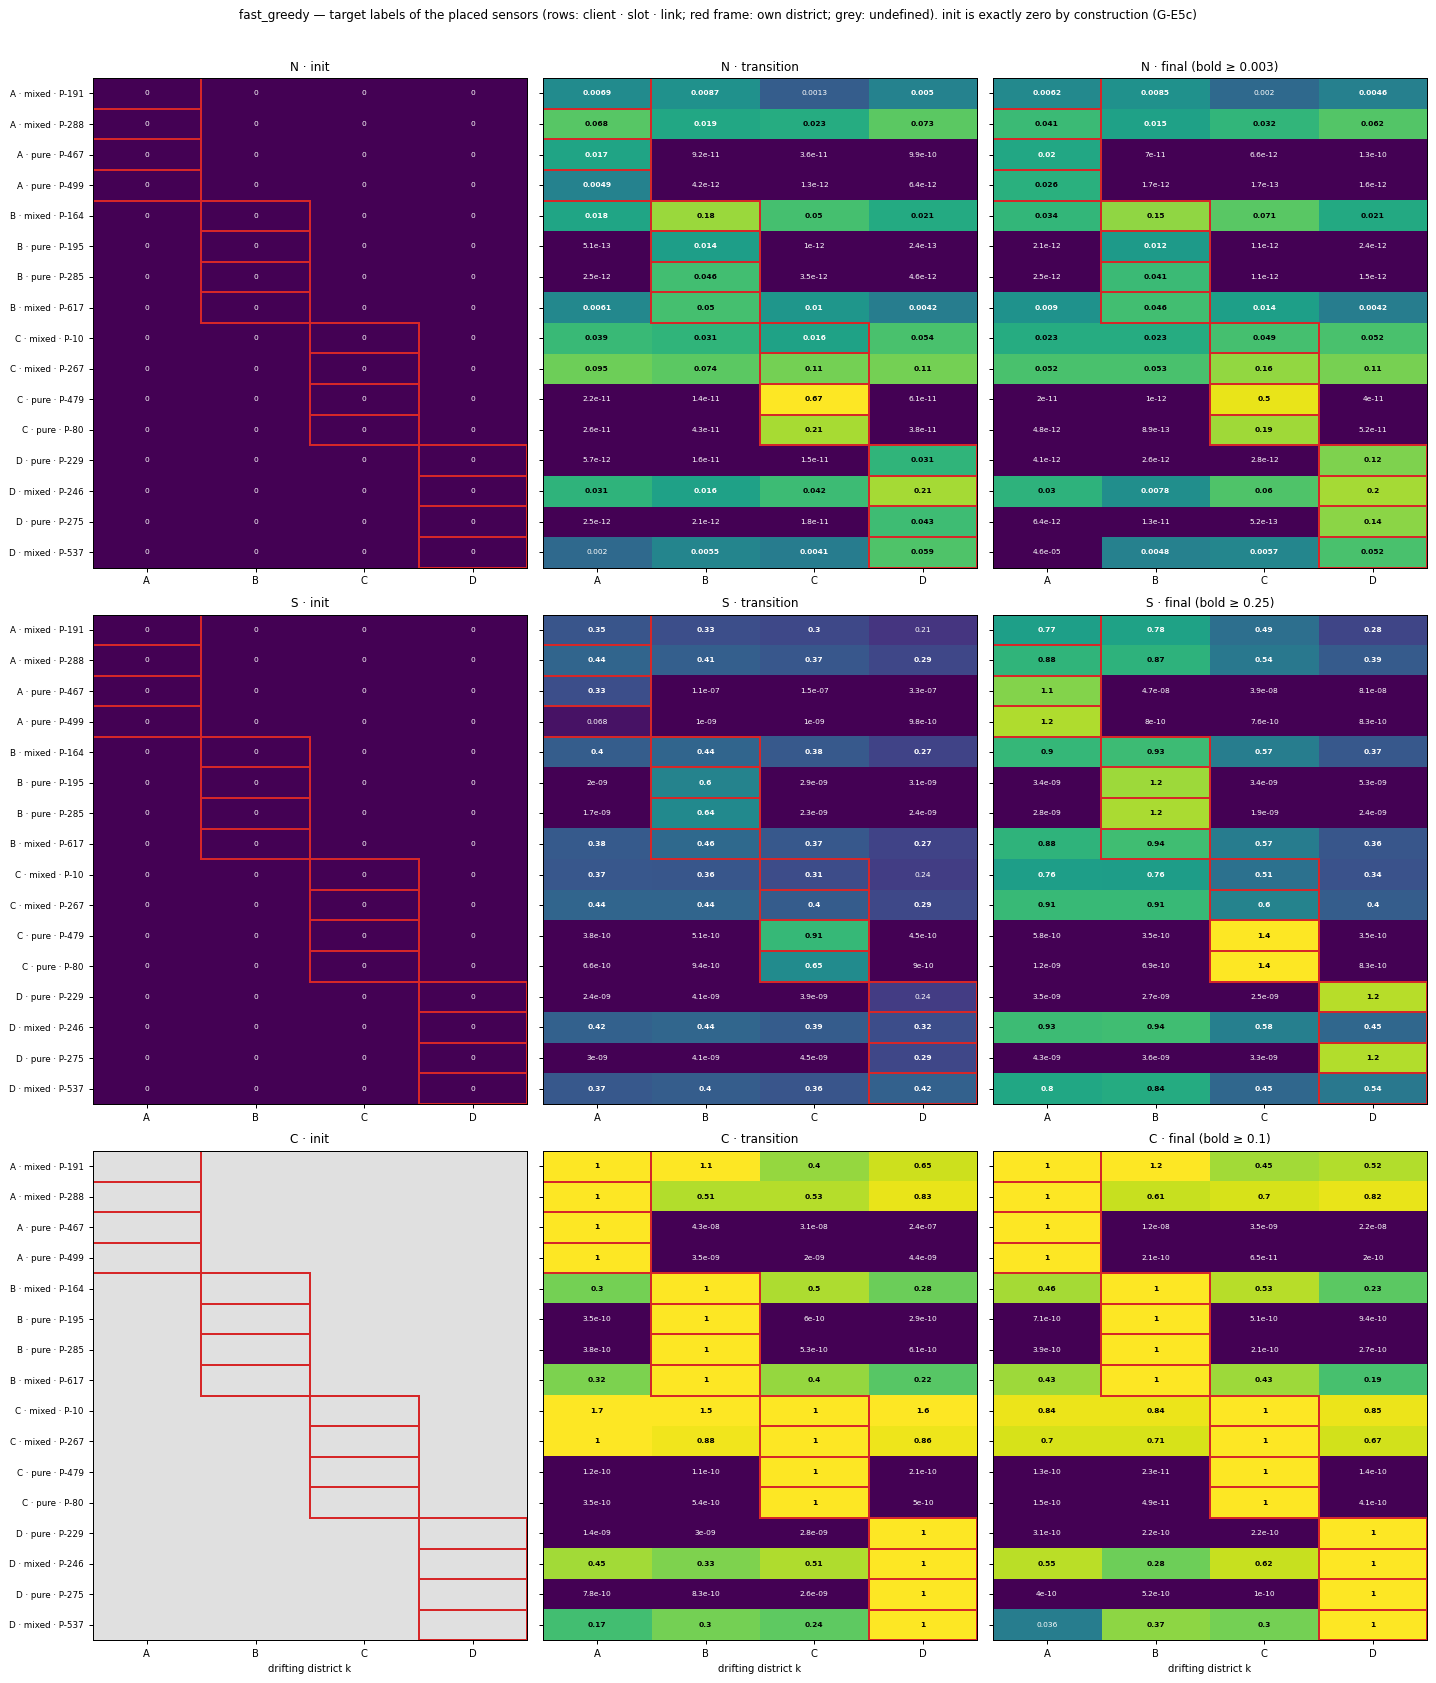

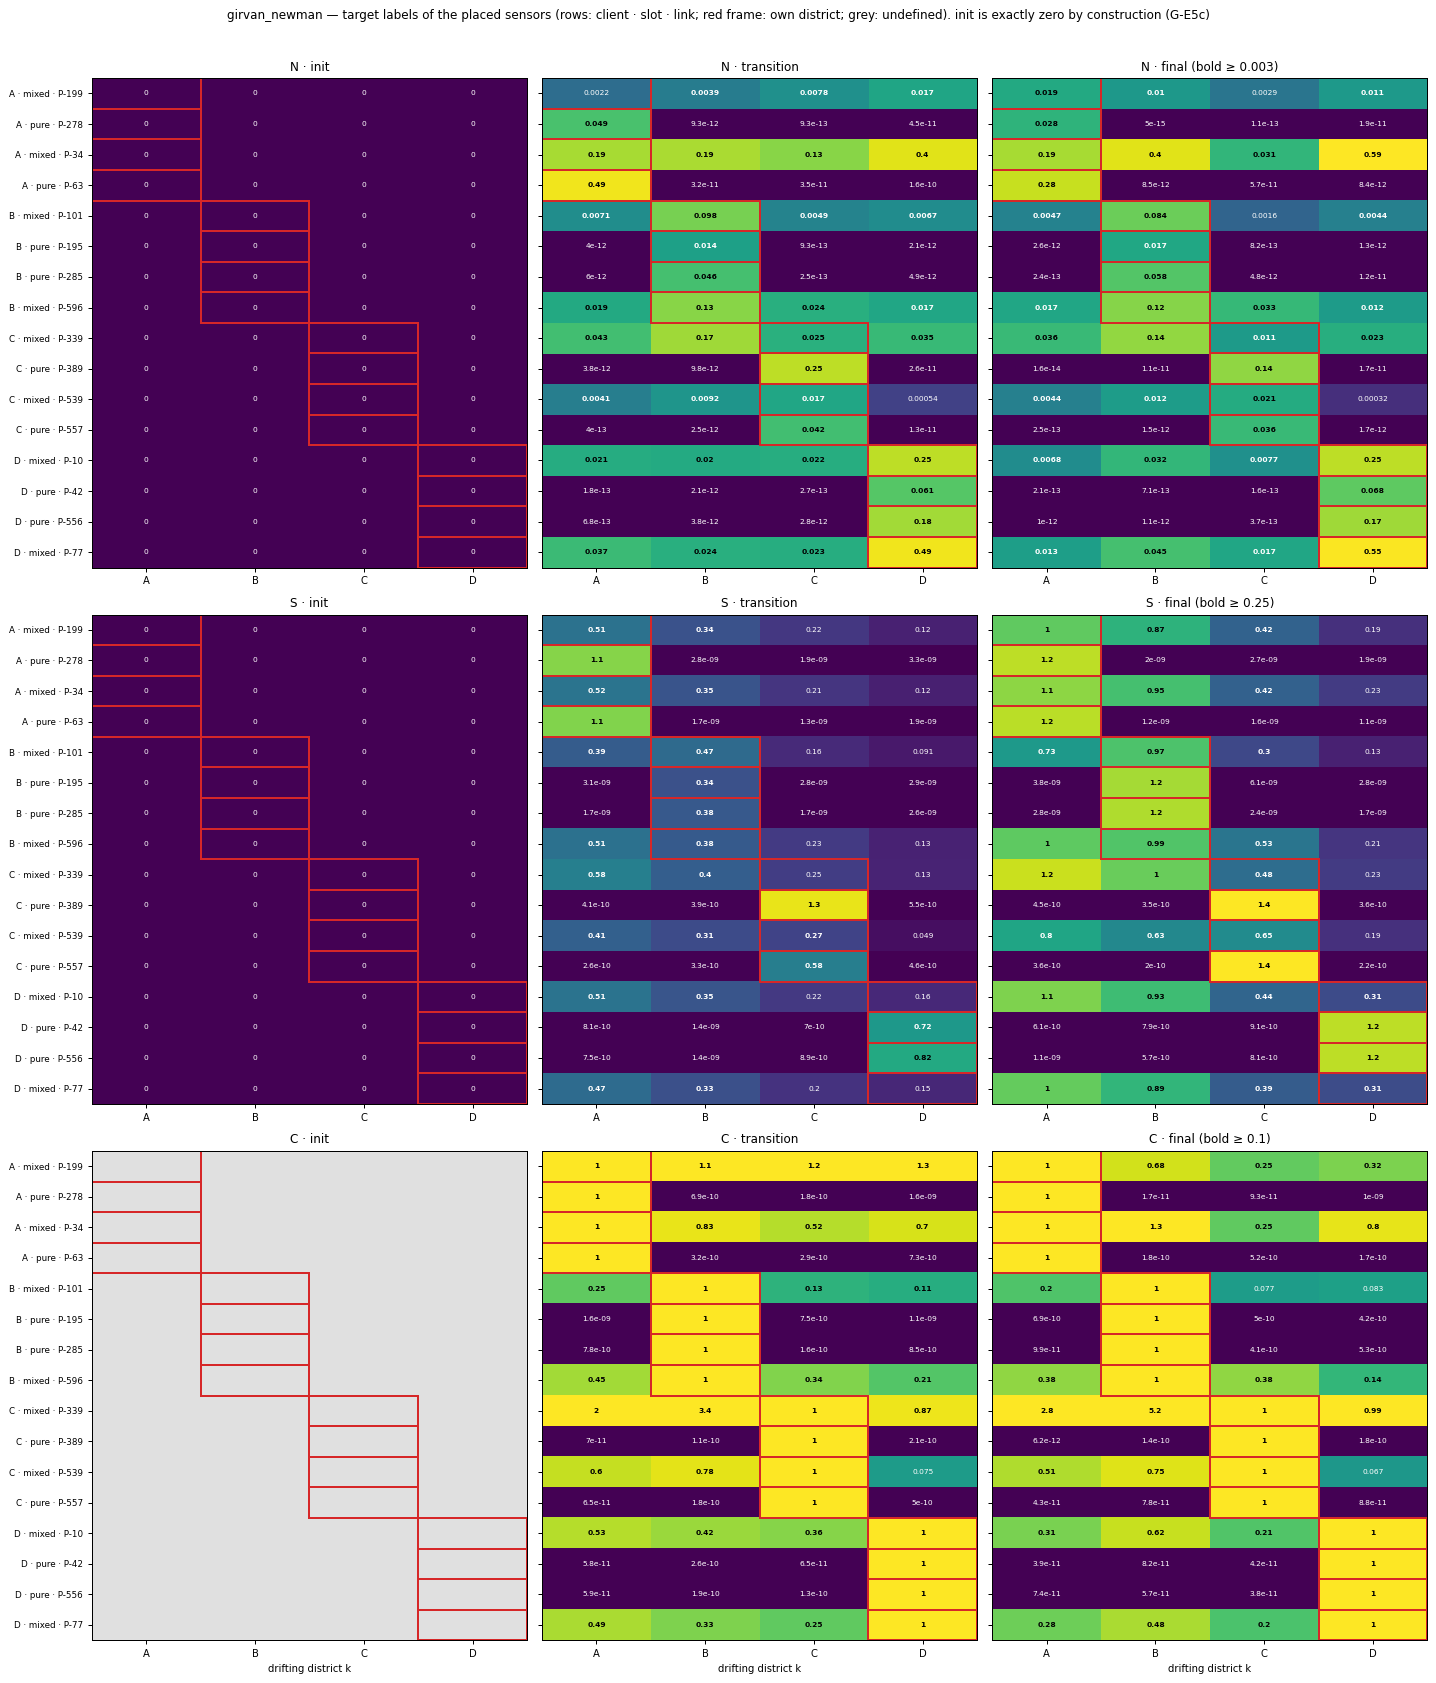

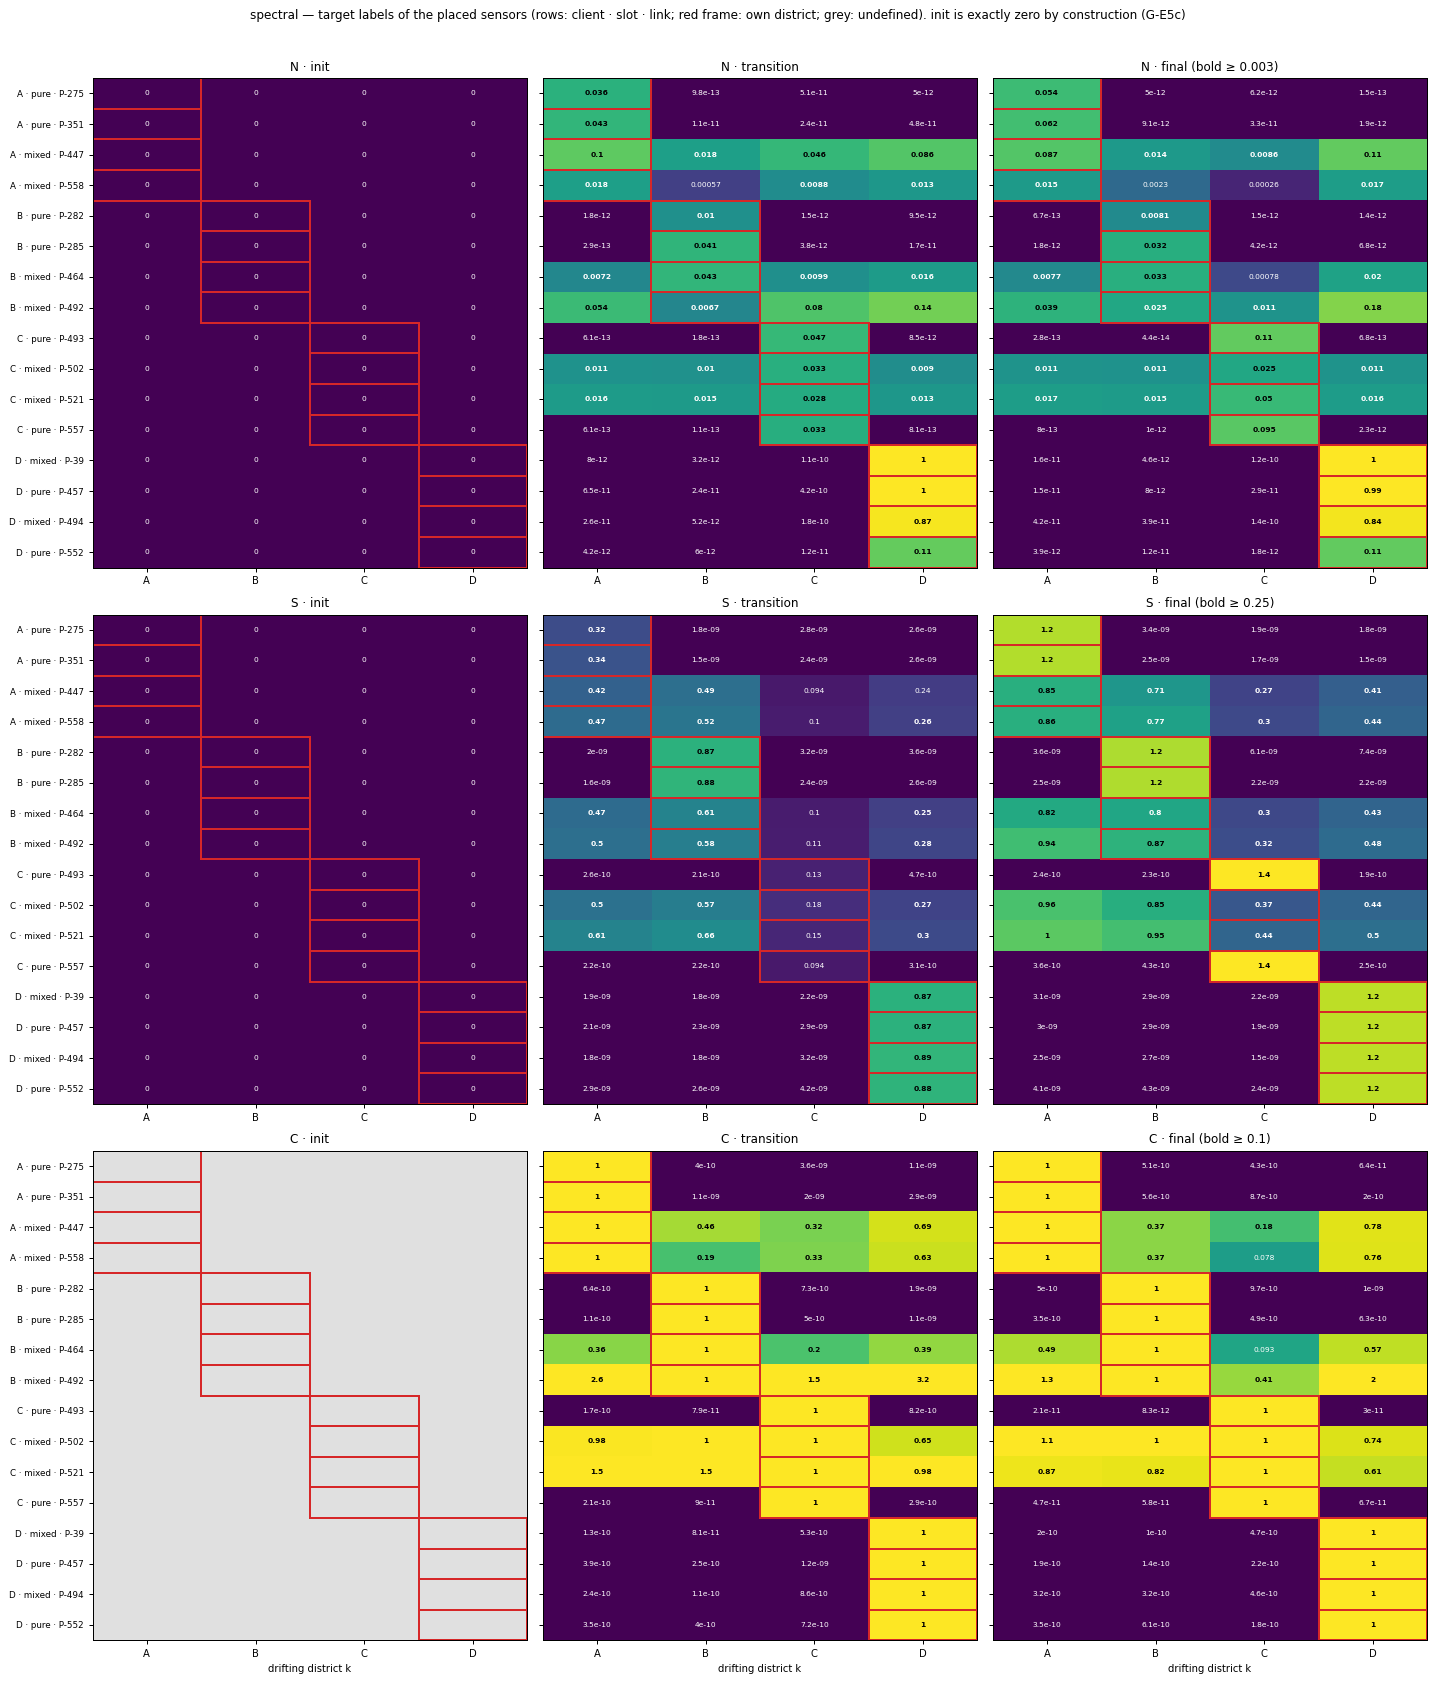

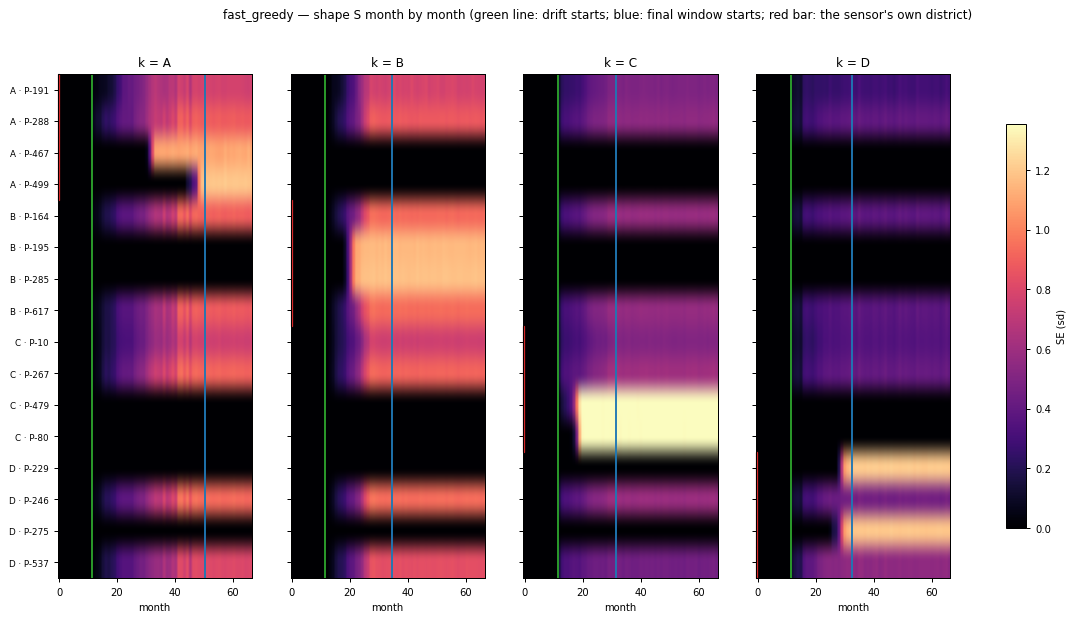

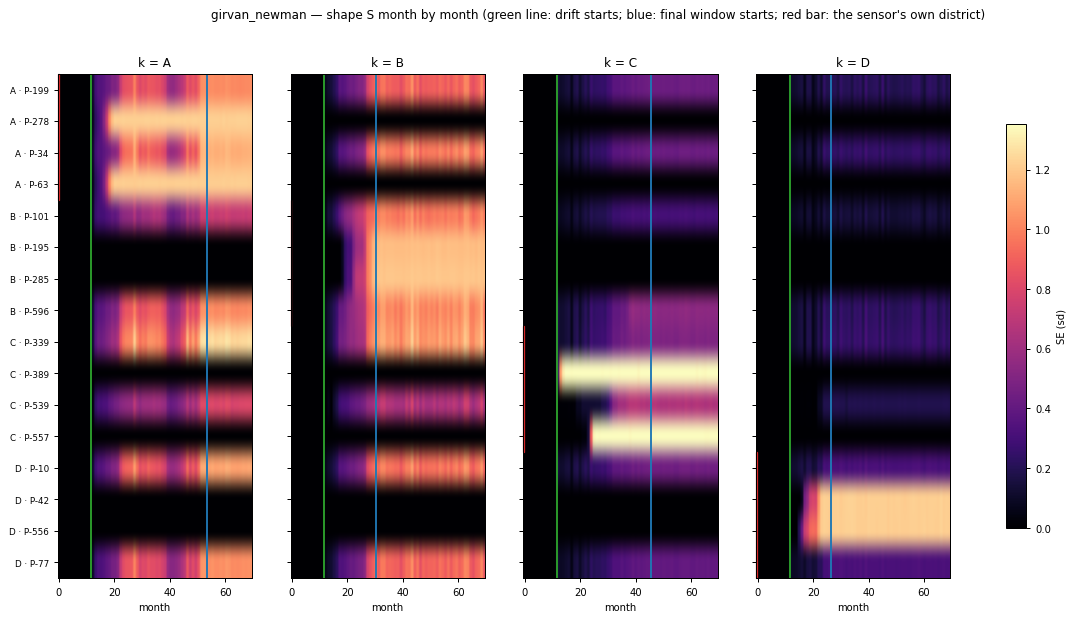

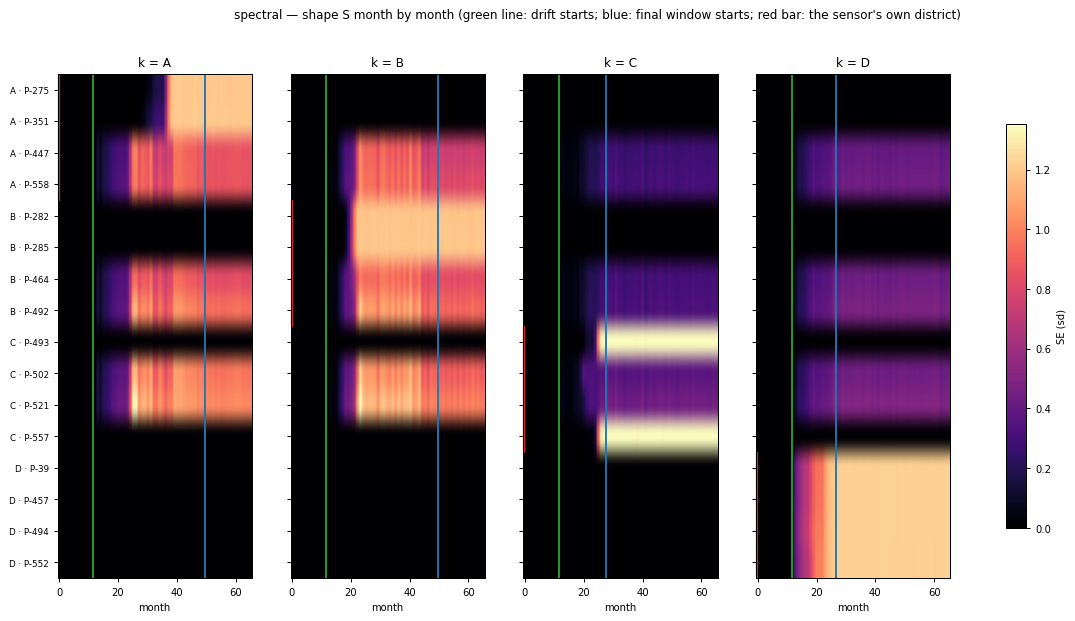

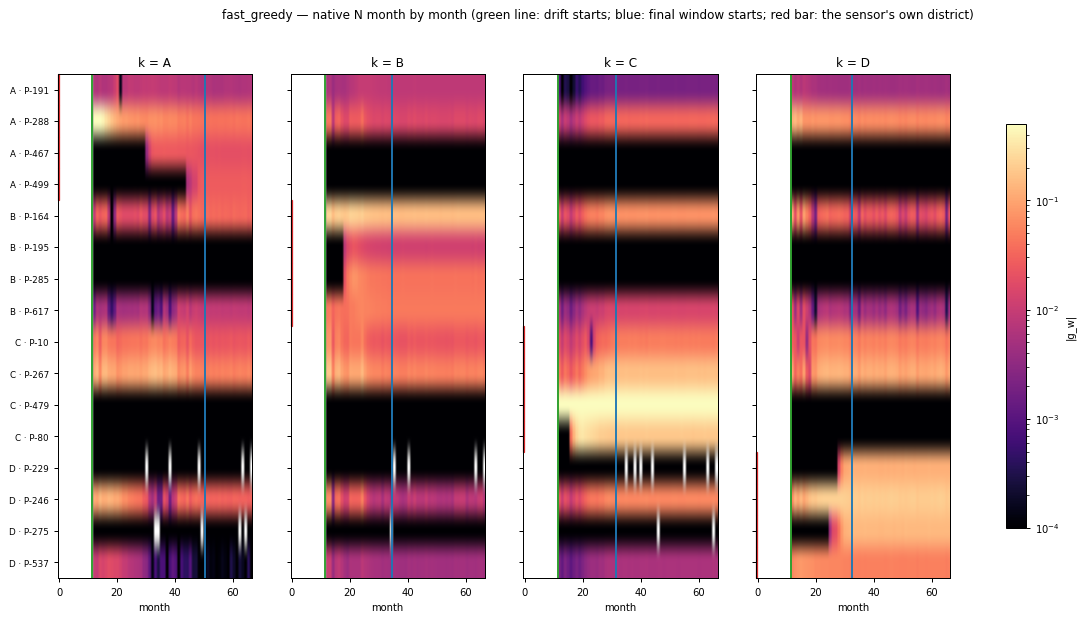

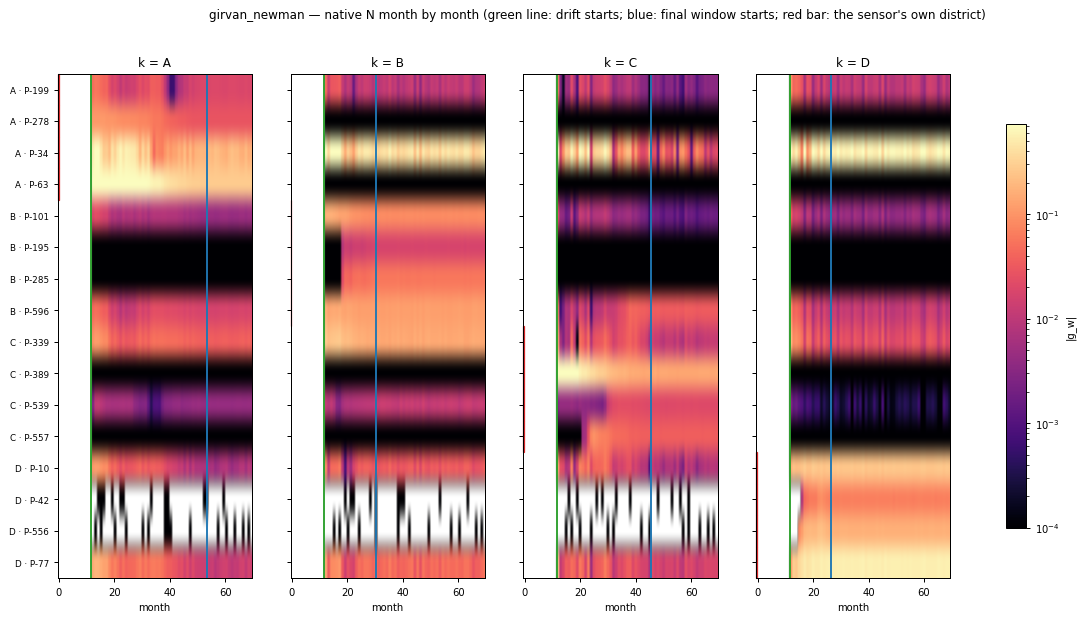

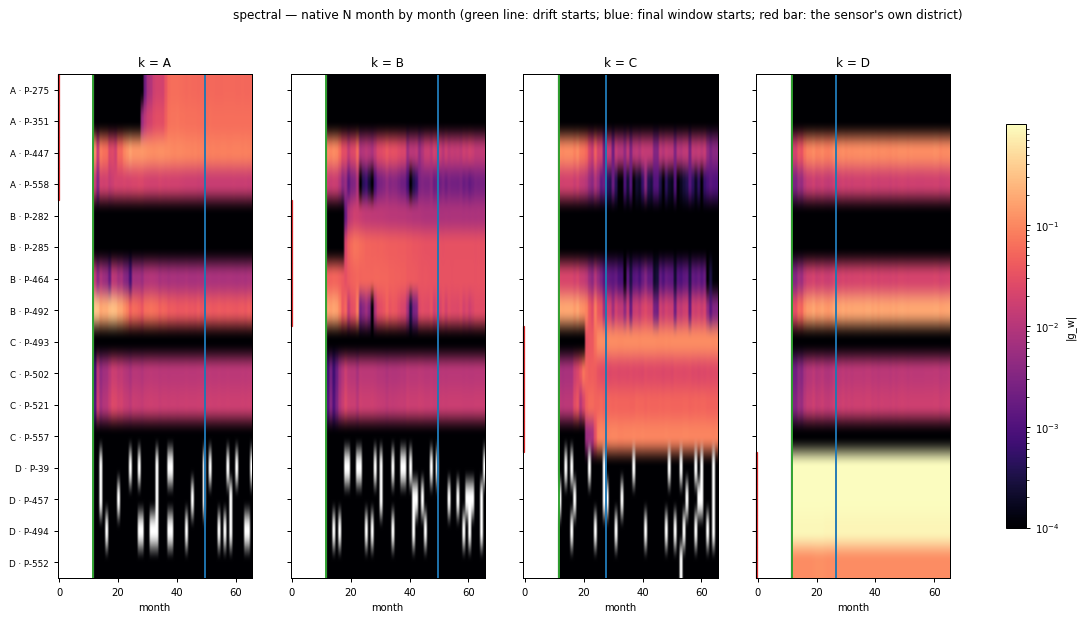

In [12]:
# L. the target labels: placed sensors x drifting district, over init / transition / final
TL = LB[(LB["set"] == "target") & (LB["step"] == 3600) & (LB["output"] == "snap") & LB["placed"]]
slot = PLC.assign(element=PLC["element"].astype(str)).drop_duplicates(["districting", "element"]).set_index(
    ["districting", "element"])["slot_class"]
NORM = {"N": lambda v: LogNorm(vmin=1e-4, vmax=max(np.nanmax(v), 1e-3)),
        "S": lambda v: plt.Normalize(vmin=0, vmax=max(np.nanmax(v), 0.5)),
        "C": lambda v: LogNorm(vmin=10 ** -2.5, vmax=1.0)}
for m in sorted(TL["districting"].unique()):
    q_ = TL[TL["districting"] == m]
    rows_ = q_.drop_duplicates("element").sort_values(["home", "element"])
    order_e = list(rows_["element"])
    ylab = [f"{h.replace('District_', '')} · {slot.get((m, e), '?')} · {e}" for h, e in zip(rows_["home"], rows_["element"])]
    ks = sorted(q_["k"].unique())
    fig, axes = plt.subplots(3, 3, figsize=(16, 3 + 1.0 * len(order_e)), squeeze=False)
    for i, x in enumerate(("N", "S", "C")):
        allv = q_[x].to_numpy(float)
        for j, per in enumerate(("init", "transition", "final")):
            ax = axes[i, j]
            A = q_[q_["period"] == per].pivot_table(index="element", columns="k", values=x).reindex(index=order_e, columns=ks)
            V = A.to_numpy(float)
            nrm = NORM[x](allv[np.isfinite(allv)] if np.isfinite(allv).any() else np.array([1.0]))
            lo_ = nrm.vmin
            Vp = np.where(np.isfinite(V), np.maximum(V, lo_), np.nan)          # exact zeros drawn at the bottom colour
            cm = plt.get_cmap("viridis").copy(); cm.set_bad("0.88")             # grey: undefined (no own response)
            ax.imshow(np.ma.masked_invalid(Vp), aspect="auto", cmap=cm, norm=nrm)
            for (a_, b_), v in np.ndenumerate(V):
                if np.isfinite(v):
                    light = nrm(max(v, lo_)) > 0.6
                    ax.text(b_, a_, "0" if v == 0 else f"{v:.2g}", ha="center", va="center", fontsize=6,
                            color="k" if light else "w", fontweight="bold" if v >= FLOOR[x] else "normal")
            hm = rows_["home"].tolist()
            for a_, h in enumerate(hm):                                       # own-district cells outlined
                if h in ks:
                    ax.add_patch(plt.Rectangle((ks.index(h) - 0.5, a_ - 0.5), 1, 1, fill=False, ec="#d62728", lw=1.6))
            ax.set_xticks(range(len(ks)), [c.replace("District_", "") for c in ks])
            ax.set_yticks(range(len(order_e)), ylab if j == 0 else [], fontsize=7)
            ax.set_title(f"{x} · {per}" + (f" (bold ≥ {FLOOR[x]:g})" if j == 2 else ""))
            if i == 2:
                ax.set_xlabel("drifting district k")
    fig.suptitle(f"{m} — target labels of the placed sensors (rows: client · slot · link; red frame: own district; grey: undefined). "
                 "init is exactly zero by construction (G-E5c)")
    fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()

# month by month: when does each label appear?
for x in ("S", "N"):
    for m in sorted(E5M["districting"].unique()):
        q_ = E5M[(E5M["districting"] == m)].merge(
            TL[["districting", "element", "home"]].drop_duplicates(), on=["districting", "element"])
        order_e = list(q_.drop_duplicates("element").sort_values(["home", "element"])["element"])
        ks = sorted(q_["k"].unique())
        fig, axes = plt.subplots(1, len(ks), figsize=(16, 2 + 0.33 * len(order_e)), squeeze=False, sharey=True)
        col = "SE" if x == "S" else "g_w"
        vals = q_[col].abs() if x == "N" else q_[col]
        vmax = np.nanquantile(vals, 0.99) if vals.notna().any() else 1
        for j, k in enumerate(ks):
            ax = axes[0, j]
            A = q_[q_["k"] == k].assign(v=lambda d: d[col].abs() if x == "N" else d[col]).pivot_table(
                index="element", columns="month", values="v").reindex(order_e)
            im = ax.imshow(A.to_numpy(float), aspect="auto", cmap="magma",
                           norm=LogNorm(vmin=1e-4, vmax=max(vmax, 1e-3)) if x == "N" else plt.Normalize(0, vmax))
            hm_ = q_.drop_duplicates("element").set_index("element")["home"]
            for a_, e in enumerate(order_e):                                  # own-district rows: red bar on the left
                if hm_.get(e) == k:
                    ax.add_patch(plt.Rectangle((-0.5, a_ - 0.5), 0.35, 1, color="#d62728", clip_on=False))
            per = PERIOD_OF.get(("target", m, k))
            if per:
                smm = int(ATLAS.world(WORLDS[WORLDS["districting"] == m].iloc[0]["sim_hash"]).params["time"]["days_per_month"]) * 24
                for edge, c in ((per["transition"][0] / smm, "#2ca02c"), (per["final"][0] / smm, "#1f77b4")):
                    ax.axvline(edge - 0.5, color=c, lw=1.5)
            ax.set(title=f"k = {k.replace('District_', '')}", xlabel="month")
            if j == 0:
                hm = q_.drop_duplicates("element").set_index("element")["home"]
                ax.set_yticks(range(len(order_e)), [f"{hm[e].replace('District_', '')} · {e}" for e in order_e], fontsize=7)
        fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label=("|g_w|" if x == "N" else "SE (sd)"))
        fig.suptitle(f"{m} — {('shape S' if x == 'S' else 'native N')} month by month (green line: drift starts; "
                     "blue: final window starts; red bar: the sensor's own district)")
        plt.show()

## B · The study's evidence vs the exact effect (target worlds, U3)

Per sensor and drifting district, final window (= the study's settled window): is the study's significance right?
Truth: exact $N\ge$ floor (native, against `sig_tot`) and exact $S\ge$ floor (shape, against `sig_shape`). Reported:
$P(\text{sig}\mid\text{exact}\approx0)$ (false positives), $P(\text{sig}\mid\text{exact responds})$, AUC of $z_{tot}$, the share of
significant cells whose study gain is mostly drift-free variation ($\lvert g_{noise}\rvert>\lvert g_{effect}\rvert$), and the
rank agreement of the study's gains with the exact ones. Rows for placed sensors as well. Section S repeats the
false-positive / recall pair across floors.

**Study vs exact** (default floors N ≥ 0.003, S ≥ 0.25; section S sweeps them). $g_{tot}=g_{effect}+g_{noise}$ exactly, $g_{noise}$ being the same settled − init gain on the no-drift city.

,districting,topo,own,n,exact N responds,P(sig | N ~0),P(sig | N responds),AUC z_tot,sig with |noise|>|effect|,Spearman g_tot vs exact,exact S responds,P(sig_shape | S ~0),P(sig_shape | S responds),Spearman g_shape vs exact
0,fast_greedy,branch,False,495,0.000,0.051,NaN,NaN,1.000,0.188,0.000,0.051,NaN,-0.109
1,fast_greedy,branch,True,165,0.752,1.000,1.000,0.494,0.000,1.000,1.000,NaN,1.000,0.989
2,fast_greedy,loop,False,1257,0.731,0.287,0.804,0.820,0.005,0.994,0.866,0.542,0.785,0.990
3,fast_greedy,loop,True,419,0.905,0.300,0.945,0.906,0.000,1.000,0.995,0.000,0.866,1.000
4,fast_greedy,source_bridge,False,48,0.750,0.000,1.000,1.000,0.000,0.969,0.750,0.000,0.778,0.511
5,fast_greedy,source_bridge,True,16,1.000,NaN,0.750,NaN,0.000,1.000,1.000,NaN,0.750,0.976
6,girvan_newman,branch,False,495,0.000,0.051,NaN,NaN,1.000,0.248,0.000,0.051,NaN,-0.052
7,girvan_newman,branch,True,165,0.764,1.000,1.000,0.730,0.000,1.000,1.000,NaN,1.000,0.973
8,girvan_newman,loop,False,1257,0.650,0.234,0.759,0.852,0.007,0.991,0.712,0.268,0.546,0.985
9,girvan_newman,loop,True,419,0.926,0.548,0.881,0.789,0.003,1.000,0.995,1.000,0.911,0.999


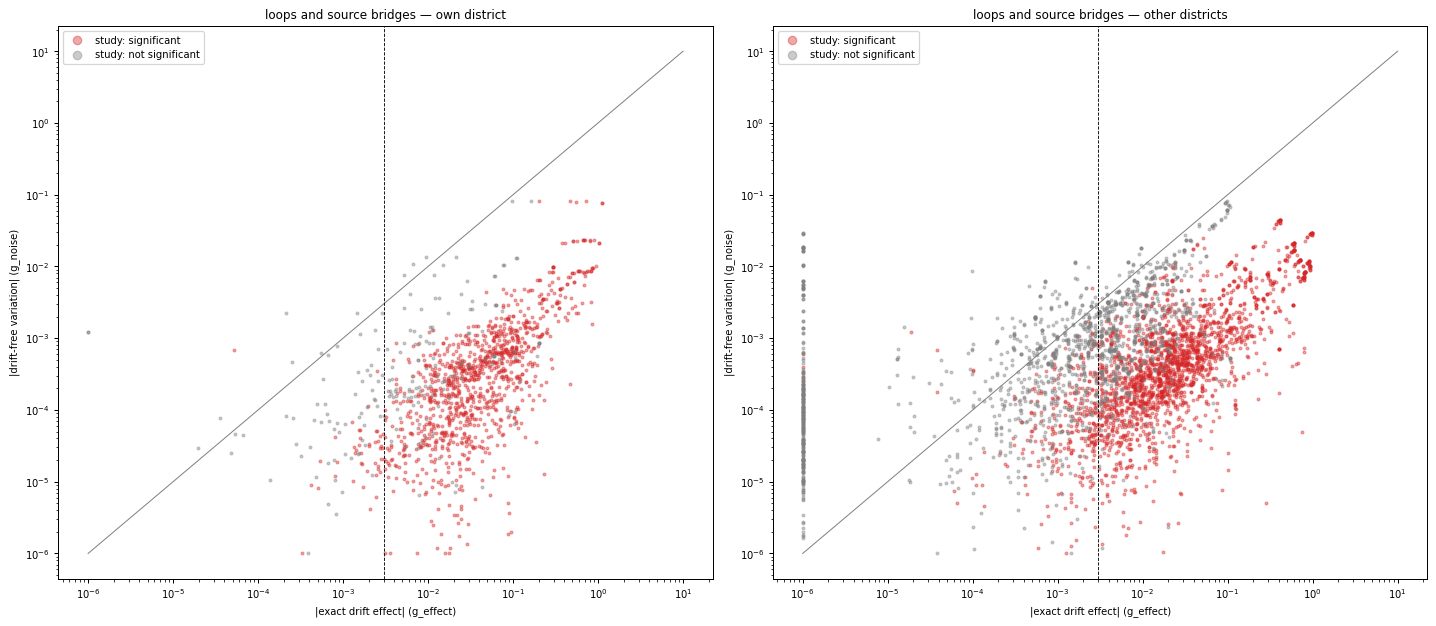

In [13]:
# B. the study's evidence vs the exact effect (target worlds, final window = the study's settled window; U3)
if not (STUDY_OK and RUN_TARGET):
    display(Markdown("**B skipped** (G-E5e failed or the target set did not run)."))
else:
    se_ = SE.assign(element=SE["element"].astype(str)).rename(columns={"drift": "k"})[
        ["districting", "k", "element", "g_tot", "orient", "z_tot", "sig_tot", "g_shape", "z_shape", "sig_shape"]]
    ex = LF[LF["set"] == "target"][["districting", "k", "element", "topo", "own", "storage", "placed", "N", "S", "C",
                                    "g_shape"]].rename(columns={"g_shape": "g_shape_exact"})
    CB = ex.merge(E5S, on=["districting", "k", "element"]).merge(se_, on=["districting", "k", "element"])
    CB["g_effect_o"] = CB["g_effect"] * CB["orient"]
    CB.to_parquet(OUT / "e5_vs_study.parquet", index=False)
    rows = []
    groups = list(CB.groupby(["districting", "topo", "own"])) + \
        [(("placed", "all", o), g) for o, g in CB[CB["placed"]].groupby("own")]
    for keys, g in groups:
        resp = g["N"] >= FLOOR["N"]
        sig = g["sig_tot"].astype(bool)
        sresp, ssig = g["S"] >= FLOOR["S"], g["sig_shape"].astype(bool)
        rows.append({"districting": keys[0], "topo": keys[1], "own": keys[2], "n": len(g),
                     "exact N responds": float(resp.mean()),
                     "P(sig | N ~0)": float(sig[~resp].mean()) if (~resp).any() else np.nan,
                     "P(sig | N responds)": float(sig[resp].mean()) if resp.any() else np.nan,
                     "AUC z_tot": auc(g[resp]["z_tot"], g[~resp]["z_tot"]),
                     "sig with |noise|>|effect|": float((g[sig]["g_noise"].abs() > g[sig]["g_effect"].abs()).mean())
                     if sig.any() else np.nan,
                     "Spearman g_tot vs exact": spear(g["g_tot"], g["g_effect_o"]),
                     "exact S responds": float(sresp.mean()),
                     "P(sig_shape | S ~0)": float(ssig[~sresp].mean()) if (~sresp).any() else np.nan,
                     "P(sig_shape | S responds)": float(ssig[sresp].mean()) if sresp.any() else np.nan,
                     "Spearman g_shape vs exact": spear(g["g_shape"], g["g_shape_exact"])})
    display(Markdown(f"**Study vs exact** (default floors N ≥ {FLOOR['N']:g}, S ≥ {FLOOR['S']:g}; section S sweeps them). "
                     "$g_{tot}=g_{effect}+g_{noise}$ exactly, $g_{noise}$ being the same settled − init gain on the no-drift city."))
    display(pd.DataFrame(rows).round(3))
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for ax, own in zip(axes, (True, False)):
        z_ = CB[(CB["own"] == own) & (CB["topo"] != "branch")]
        for sg_, cc in ((True, "#d62728"), (False, "#7f7f7f")):
            q_ = z_[z_["sig_tot"].astype(bool) == sg_]
            ax.scatter(q_["g_effect"].abs().clip(1e-6), q_["g_noise"].abs().clip(1e-6), s=5, alpha=0.4, color=cc,
                       label="study: significant" if sg_ else "study: not significant")
        ax.plot([1e-6, 10], [1e-6, 10], color="0.5", lw=0.8)
        ax.axvline(FLOOR["N"], color="k", lw=0.7, ls="--")
        ax.set(xscale="log", yscale="log", xlabel="|exact drift effect| (g_effect)",
               ylabel="|drift-free variation| (g_noise)",
               title=f"loops and source bridges — {'own district' if own else 'other districts'}")
        ax.legend(markerscale=3)
    fig.tight_layout(); plt.show()

## C · The label stack's gate vs the exact effect; D · probe vs target (U4)

**C.** In the probe worlds a cell is live if $\lvert proj\rvert>1.5\,\nu$ (`stack_gains`, shape space); scored against the
exact N and S there. **D.** The exact effect of the same district's drift on the same link in the probe world and in
the target world, per metric: if these agree, the probe-vs-target disagreement in the stack was estimation, not physics.

**C · The label stack's gate** ($\lvert proj\rvert>1.5\,\nu$, shape space) against the exact effect in the same probe worlds

,districting,topo,own,n,P(live | N ~0),P(live | N responds),P(live | S ~0),P(live | S responds)
0,fast_greedy,branch,False,495,0.325,NaN,0.325,NaN
1,fast_greedy,branch,True,165,1.000,1.000,NaN,1.000
2,fast_greedy,loop,False,1257,0.835,0.985,0.716,0.981
3,fast_greedy,loop,True,419,0.900,0.987,0.000,0.983
4,fast_greedy,source_bridge,False,51,0.333,1.000,0.333,1.000
5,fast_greedy,source_bridge,True,17,NaN,1.000,NaN,1.000
6,girvan_newman,branch,False,495,0.323,NaN,0.323,NaN
7,girvan_newman,branch,True,165,1.000,1.000,NaN,1.000
8,girvan_newman,loop,False,1257,0.765,0.836,0.718,0.846
9,girvan_newman,loop,True,419,0.875,0.992,1.000,0.983


**D · Probe vs target design** — exact effect of the same district's drift on the same link in the probe world (stack design, seed 42) and the target world (study design, seed 43); agreement at the default floors

,districting,topo,own,n,Spearman N,agree N,Spearman S,agree S,Spearman C,agree C
0,fast_greedy,branch,False,495,0.830,1.000,0.970,1.000,0.915,1.000
1,fast_greedy,branch,True,165,1.000,0.982,0.925,1.000,NaN,1.000
2,fast_greedy,loop,False,1257,0.998,0.986,1.000,0.999,0.999,0.983
3,fast_greedy,loop,True,419,1.000,1.000,1.000,1.000,NaN,0.993
4,fast_greedy,source_bridge,False,51,0.982,1.000,0.994,1.000,0.991,1.000
5,fast_greedy,source_bridge,True,17,0.997,1.000,0.997,1.000,NaN,1.000
6,girvan_newman,branch,False,495,0.776,1.000,0.979,1.000,0.902,1.000
7,girvan_newman,branch,True,165,0.999,0.994,0.901,1.000,NaN,0.994
8,girvan_newman,loop,False,1257,0.992,0.967,1.000,0.986,0.993,0.987
9,girvan_newman,loop,True,419,1.000,0.998,0.988,1.000,NaN,1.000


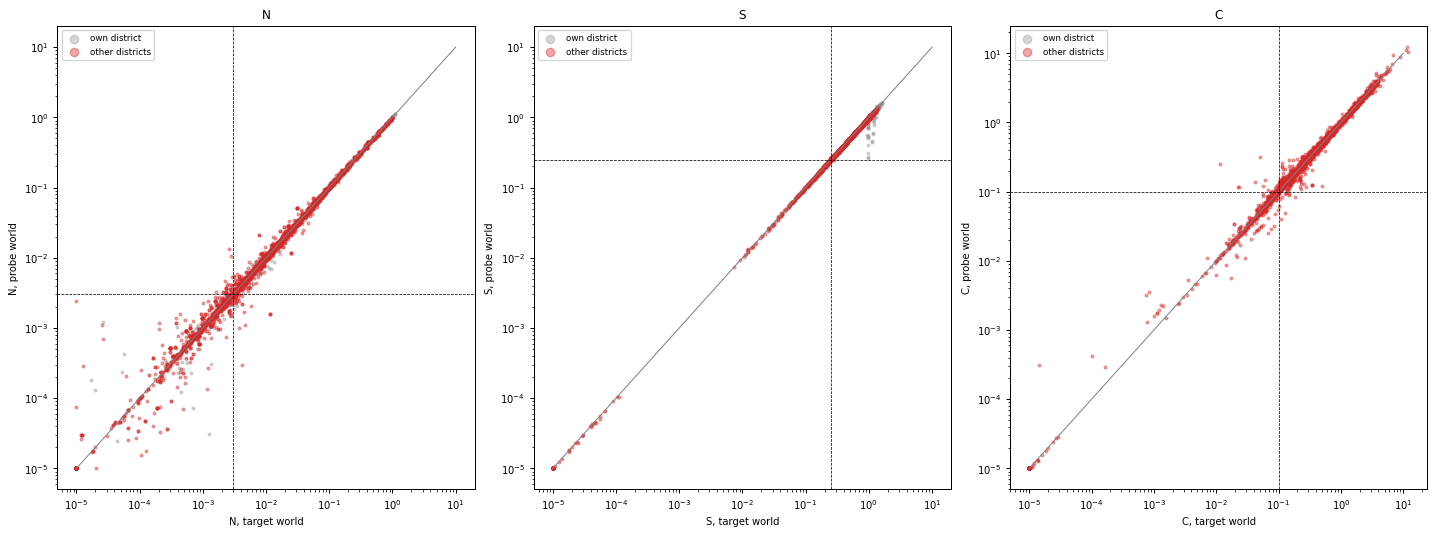

In [14]:
# C. the label stack's gate vs the exact effect in its own probe worlds; D. probe vs target exact effects (U4)
if not (CORE_OK and RUN_PROBE):
    display(Markdown("**C/D skipped** (core gate failed or the probe set did not run)."))
else:
    ex = LF[LF["set"] == "probe"]
    sg_ = SG[SG["kind"] == "flow"].assign(element=SG["element"].astype(str)).rename(columns={"drift_district": "k"})
    sg_["live"] = sg_["proj"].abs() > NULL_FACTOR * sg_["nu"]
    CC = ex.merge(sg_[["districting", "k", "element", "live", "proj", "nu"]], on=["districting", "k", "element"])
    CC.to_parquet(OUT / "e5_vs_stack.parquet", index=False)
    rows = []
    for (m, tp_, own), g in CC.groupby(["districting", "topo", "own"]):
        row = {"districting": m, "topo": tp_, "own": own, "n": len(g)}
        for x in ("N", "S"):
            resp = g[x] >= FLOOR[x]
            row[f"P(live | {x} ~0)"] = float(g[~resp]["live"].mean()) if (~resp).any() else np.nan
            row[f"P(live | {x} responds)"] = float(g[resp]["live"].mean()) if resp.any() else np.nan
        rows.append(row)
    display(Markdown(f"**C · The label stack's gate** ($\\lvert proj\\rvert>{NULL_FACTOR}\\,\\nu$, shape space) against the exact "
                     "effect in the same probe worlds"))
    display(pd.DataFrame(rows).round(3))
    if RUN_TARGET:
        tg = LF[LF["set"] == "target"]
        PV = tg.merge(ex, on=["districting", "k", "element"], suffixes=("_t", "_p"))
        PV.to_parquet(OUT / "e5_probe_vs_target.parquet", index=False)
        rows = []
        for keys, g in list(PV.groupby(["districting", "topo_t", "own_t"])) + \
                [(("placed", "all", o), g) for o, g in PV[PV["placed_t"]].groupby("own_t")]:
            row = {"districting": keys[0], "topo": keys[1], "own": keys[2], "n": len(g)}
            for x in ("N", "S", "C"):
                row[f"Spearman {x}"] = spear(g[f"{x}_t"], g[f"{x}_p"])
                a_, b_ = g[f"{x}_t"] >= FLOOR[x], g[f"{x}_p"] >= FLOOR[x]
                row[f"agree {x}"] = float((a_ == b_).mean())
            rows.append(row)
        display(Markdown("**D · Probe vs target design** — exact effect of the same district's drift on the same link in the "
                         "probe world (stack design, seed 42) and the target world (study design, seed 43); agreement at "
                         "the default floors"))
        display(pd.DataFrame(rows).round(3))
        fig, axes = plt.subplots(1, 3, figsize=(16, 6))
        for ax, x in zip(axes, ("N", "S", "C")):
            for own, cc in ((True, "0.6"), (False, "#d62728")):
                q_ = PV[PV["own_t"] == own]
                ax.scatter(q_[f"{x}_t"].clip(1e-5), q_[f"{x}_p"].clip(1e-5), s=5, alpha=0.4, color=cc,
                           label="own district" if own else "other districts")
            ax.plot([1e-5, 10], [1e-5, 10], color="0.5", lw=0.8)
            ax.axvline(FLOOR[x], color="k", lw=0.6, ls="--"); ax.axhline(FLOOR[x], color="k", lw=0.6, ls="--")
            ax.set(xscale="log", yscale="log", xlabel=f"{x}, target world", ylabel=f"{x}, probe world", title=x)
            ax.legend(markerscale=3, fontsize=7)
        fig.tight_layout(); plt.show()

## E · Measurement model and hydraulic step

Against the stored setting (3600 s, snapshots), final window: rank agreement of N, S and C, the share of labels that
flip at the default floor, and the median relative change of responding cells, when the sensor reads hour averages
or (D-Town) when the hydraulic step is 900 s.

## Files

| file | one row per |
|---|---|
| `e5_link` | set × partition × district × step × output × period × link: all metrics and annotations |
| `e5_labels` | as `e5_link`, plus N, S, own-relative N and S, C (dead and unassigned links dropped) |
| `e5_monthly` | partition × district × month × link (target, stored setting): $g_w$, S, RE |
| `e5_matrix` | set × partition × scope × metric × (j, k) |
| `e5_sensitivity` | set × partition × metric × floor |
| `e5_study_basis`, `e5_vs_study` | $g_{tot}$ recomputed, $g_{effect}$, $g_{noise}$; joined with `sensor_evidence` |
| `e5_vs_stack`, `e5_probe_vs_target`, `e5_model_step` | sections C, D, E |
| `e5_gate`, `e5_splice`, `e5_branch`, `e5_runs` | gates |
| `series/*.npz` | hourly flow of the placed sensors, pump states and district demand, per target world and the no-drift city |

In [15]:
# E. does the measurement model (snapshot / hour average) or the hydraulic step change the labels?
keys = ["set", "districting", "k", "element", "topo", "own"]
rows = []
for x in ("N", "S", "C"):
    V = LB[LB["period"] == "final"].pivot_table(index=keys, columns=["step", "output"], values=x)
    V.columns = [f"{s}_{o}" for s, o in V.columns]
    V = V.reset_index()
    for c in [c for c in V.columns if c.endswith(("_snap", "_avg")) and c != "3600_snap"]:
        for (s_, m, own), g in V.groupby(["set", "districting", "own"]):
            ok = g["3600_snap"].notna() & g[c].notna()
            rows.append({"metric": x, "set": s_, "districting": m, "own": own, "vs": c, "n": int(ok.sum()),
                         "Spearman": spear(g["3600_snap"][ok], g[c][ok]),
                         "label flips": float(((g["3600_snap"] >= FLOOR[x]) != (g[c] >= FLOOR[x]))[ok].mean()),
                         "median rel change": float(((g[c] - g["3600_snap"]).abs() / g["3600_snap"].abs())[
                             ok & (g["3600_snap"] >= FLOOR[x])].median())})
ME = pd.DataFrame(rows)
ME.to_parquet(OUT / "e5_model_step.parquet", index=False)
display(Markdown("**Measurement model and hydraulic step** — against the stored setting (3600 s, snapshots), final window, "
                 "at the default floors"))
display(ME.round(3))
display(Markdown("files")); display(pd.DataFrame([{"file": f.name, "rows": len(pd.read_parquet(f))}
                                                 for f in sorted(OUT.glob("*.parquet"))]))

**Measurement model and hydraulic step** — against the stored setting (3600 s, snapshots), final window, at the default floors

,metric,set,districting,own,vs,n,Spearman,label flips,median rel change
0,N,probe,fast_greedy,False,900_avg,1803,0.966,0.055,0.184
1,N,probe,fast_greedy,True,900_avg,601,0.991,0.015,0.020
2,N,probe,girvan_newman,False,900_avg,1803,0.975,0.065,0.505
3,N,probe,girvan_newman,True,900_avg,601,0.996,0.010,0.034
4,N,probe,spectral,False,900_avg,1803,0.986,0.038,0.136
5,N,probe,spectral,True,900_avg,601,0.983,0.038,0.043
6,N,target,fast_greedy,False,900_avg,1803,0.968,0.052,0.183
7,N,target,fast_greedy,True,900_avg,601,0.992,0.017,0.019
8,N,target,girvan_newman,False,900_avg,1803,0.978,0.047,0.385
9,N,target,girvan_newman,True,900_avg,601,0.997,0.007,0.030


files

,file,rows
0,e5_branch.parquet,15840
1,e5_gate.parquet,48
2,e5_labels.parquet,173088
3,e5_link.parquet,173952
4,e5_matrix.parquet,576
5,e5_model_step.parquet,108
6,e5_monthly.parquet,490448
7,e5_probe_vs_target.parquet,7212
8,e5_runs.parquet,60
9,e5_sensitivity.parquet,234
